# Information-Adaptive Latent Distributional Robustness for Climate-Transition Portfolio Choice

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.10%2B-3776AB?logo=python&logoColor=white" alt="Python">
  <img src="https://img.shields.io/badge/PyTorch-CUDA-EE4C2C?logo=pytorch&logoColor=white" alt="PyTorch CUDA">
  <img src="https://img.shields.io/badge/NVIDIA-CUDA-76B900?logo=nvidia&logoColor=white" alt="NVIDIA CUDA">
  <img src="https://img.shields.io/badge/Reproducibility-Enabled-success" alt="Reproducible">
  <img src="https://img.shields.io/badge/Research-Code-blue" alt="Research Code">
</p>

## Overview

This repository contains the computational implementation accompanying the paper

> **Information-Adaptive Latent Distributional Robustness for Climate-Transition Portfolio Choice**

The code reproduces the two main computational components of the study:

1. the **Empirical Results**, based on a recursive out-of-sample portfolio experiment with climate-transition, competing-state, robustness, placebo, and statistical-inference analyses.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import matplotlib as mpl

from scipy.stats import spearmanr

from matplotlib.lines import Line2D

import seaborn as sns
from matplotlib.patches import Patch

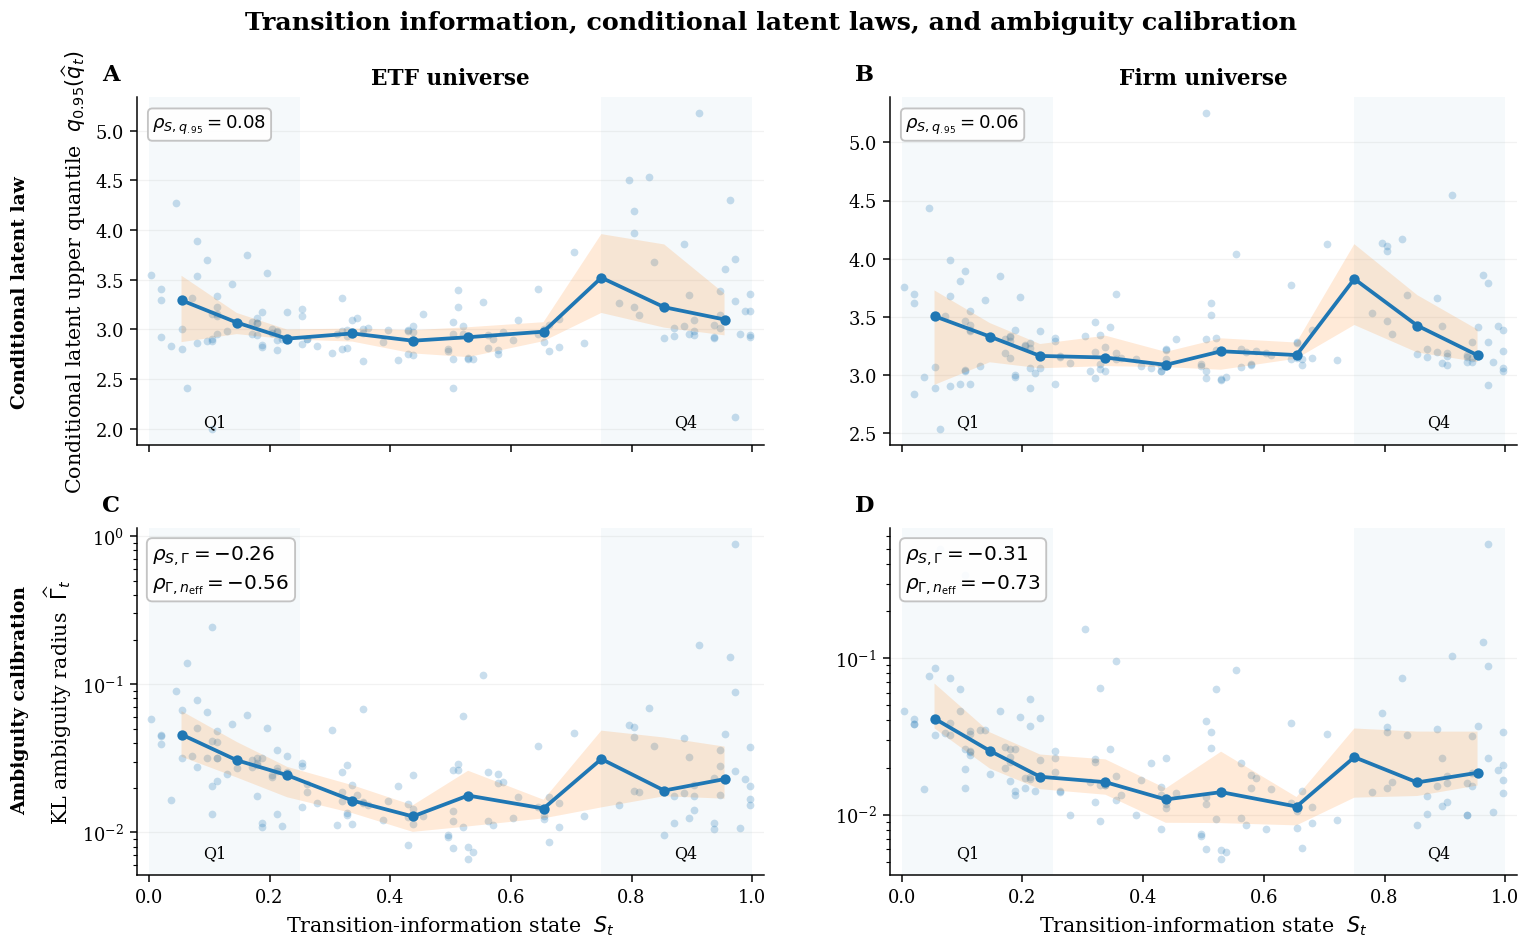

In [2]:
# =============================================================================
# FIGURE 1
# =============================================================================

from pathlib import Path

INPUT_FILE = Path(
    r"C:/Users/fredy/Downloads/Section6_Q1PP_Results_V7_FIXED/"
    r"csv/fig1_empirical_state_latent_mapping.csv"
)

UNIVERSES = ["ETF", "Firm"]
N_STATE_BINS = 10

STATE_IS_PERCENTILE_RANK = True


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10.5,
        "axes.labelsize": 11,
        "axes.titlesize": 11.5,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.08,
        "figure.dpi": 135,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


df = pd.read_csv(INPUT_FILE)

required_columns = ["Universe", "Date", "S", "q_xi_q95", "Gamma", "n_eff", "B_valid"]

missing_columns = [col for col in required_columns if col not in df.columns]

df = df[required_columns].copy()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

numeric_columns = ["S", "q_xi_q95", "Gamma", "n_eff", "B_valid"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Universe", "Date", "S", "q_xi_q95", "Gamma", "n_eff",]).copy()

df = df[df["Universe"].isin(UNIVERSES)].copy()

df = (df.sort_values(["Universe", "Date"]).reset_index(drop=True))


state_edges = np.linspace(0.0, 1.0, N_STATE_BINS + 1)

df["StateBin"] = pd.cut(
    df["S"],
    bins=state_edges,
    include_lowest=True,
    labels=False,
)

df["StateBin"] = df["StateBin"].astype(int)


# =============================================================================
# 5. WITHIN-BIN SUMMARIES
# =============================================================================

def summarize_by_state_bin(data, variable):

    return (
        data
        .groupby(
            ["Universe", "StateBin"],
            observed=True
        )
        .agg(
            S_med=("S", "median"),
            y_med=(variable, "median"),
            y_q25=(variable, lambda x: x.quantile(0.25)),
            y_q75=(variable, lambda x: x.quantile(0.75)),
            n=(variable, "size"),
        )
        .reset_index()
    )


summary_q = summarize_by_state_bin(df,"q_xi_q95")

summary_g = summarize_by_state_bin(df,"Gamma")


stats_rows = []

for universe in UNIVERSES:

    g = df[df["Universe"] == universe].copy()

    rho_q, _ = spearmanr(
        g["S"],
        g["q_xi_q95"],
        nan_policy="omit")

    rho_g, _ = spearmanr(
        g["S"],
        g["Gamma"],
        nan_policy="omit")

    rho_neff, _ = spearmanr(
        g["Gamma"],
        g["n_eff"],
        nan_policy="omit")

    stats_rows.append(
        {
            "Universe": universe,
            "N": len(g),
            "rho_S_q95": rho_q,
            "rho_S_Gamma": rho_g,
            "rho_Gamma_neff": rho_neff,
        }
    )

stats = pd.DataFrame(stats_rows)

def get_quartile_regions(g):

    if STATE_IS_PERCENTILE_RANK:
        q25 = 0.25
        q75 = 0.75
        lower = 0.00
        upper = 1.00
    else:
        q25 = float(g["S"].quantile(0.25))
        q75 = float(g["S"].quantile(0.75))
        lower = float(g["S"].min())
        upper = float(g["S"].max())

    return lower, q25, q75, upper


fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.4, 7.2),
    sharex=True,
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.088,
    right=0.985,
    bottom=0.105,
    top=0.905,
    wspace=0.20,
    hspace=0.24
)


for j, universe in enumerate(UNIVERSES):

    g = (df[df["Universe"] == universe].copy())

    sq = (summary_q[summary_q["Universe"] == universe].sort_values("StateBin").copy())

    sg = (summary_g[summary_g["Universe"] == universe].sort_values("StateBin").copy())

    st = (stats[stats["Universe"] == universe].iloc[0])

    q_lower, q25, q75, q_upper = get_quartile_regions(g)

    # =========================================================================
    # TOP ROW — CONDITIONAL LATENT LAW
    # =========================================================================

    ax = axes[0, j]

    # Lowest/highest transition-information quartiles.
    ax.axvspan(
        q_lower,
        q25,
        alpha=0.045,
        zorder=0
    )

    ax.axvspan(
        q75,
        q_upper,
        alpha=0.045,
        zorder=0
    )

    # Date-level recursive estimates.
    ax.scatter(
        g["S"],
        g["q_xi_q95"],
        s=17,
        alpha=0.24,
        linewidths=0,
        rasterized=True,
        zorder=1
    )

    # Within-state-bin interquartile range.
    ax.fill_between(
        sq["S_med"].to_numpy(),
        sq["y_q25"].to_numpy(),
        sq["y_q75"].to_numpy(),
        alpha=0.16,
        linewidth=0,
        zorder=2
    )

    # Within-state-bin median.
    ax.plot(
        sq["S_med"],
        sq["y_med"],
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        zorder=3
    )

    # Descriptive rank association.
    ax.text(
        0.025,
        0.955,
        rf"$\rho_{{S,q_{{.95}}}}={st['rho_S_q95']:.2f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.7,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.92
        )
    )

    # Q1/Q4 labels.
    ax.text(
        0.125,
        0.04,
        "Q1",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5
    )

    ax.text(
        0.875,
        0.04,
        "Q4",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5
    )

    ax.set_title(
        f"{universe} universe",
        fontweight="semibold",
        pad=7
    )

    ax.set_xlim(-0.02, 1.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.16,
        linewidth=0.7
    )

    # =========================================================================
    # BOTTOM ROW — AMBIGUITY CALIBRATION
    # =========================================================================

    ax = axes[1, j]

    ax.axvspan(
        q_lower,
        q25,
        alpha=0.045,
        zorder=0
    )

    ax.axvspan(
        q75,
        q_upper,
        alpha=0.045,
        zorder=0
    )

    ax.scatter(
        g["S"],
        g["Gamma"],
        s=17,
        alpha=0.24,
        linewidths=0,
        rasterized=True,
        zorder=1
    )

    ax.fill_between(
        sg["S_med"].to_numpy(),
        sg["y_q25"].to_numpy(),
        sg["y_q75"].to_numpy(),
        alpha=0.16,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        sg["S_med"],
        sg["y_med"],
        marker="o",
        markersize=4.5,
        linewidth=2.0,
        zorder=3
    )

    ax.set_yscale("log")

    ax.text(
        0.025,
        0.955,
        (
            rf"$\rho_{{S,\Gamma}}={st['rho_S_Gamma']:.2f}$"
            "\n"
            rf"$\rho_{{\Gamma,n_{{\mathrm{{eff}}}}}}="
            rf"{st['rho_Gamma_neff']:.2f}$"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.7,
        linespacing=1.30,
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.92
        )
    )

    ax.text(
        0.125,
        0.04,
        "Q1",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5
    )

    ax.text(
        0.875,
        0.04,
        "Q4",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.5
    )

    ax.set_xlim(-0.02, 1.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        which="major",
        alpha=0.16,
        linewidth=0.7
    )


axes[0, 0].set_ylabel(r"Conditional latent upper quantile  $q_{0.95}(\widehat q_t)$")

axes[1, 0].set_ylabel(r"KL ambiguity radius  $\widehat{\Gamma}_t$")

axes[1, 0].set_xlabel(r"Transition-information state  $S_t$")

axes[1, 1].set_xlabel(r"Transition-information state  $S_t$")

for ax in axes.flat:
    ax.set_xticks(np.linspace(0, 1, 6))

panel_labels = ["A", "B", "C", "D"]

for ax, lab in zip(axes.flat, panel_labels):
    ax.text(
        -0.055,
        1.035,
        lab,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="left"
    )

fig.text(
    0.012,
    0.705,
    "Conditional latent law",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
    fontweight="semibold"
)

fig.text(
    0.012,
    0.285,
    "Ambiguity calibration",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
    fontweight="semibold"
)

fig.suptitle(
    "Transition information, conditional latent laws, and ambiguity calibration",
    fontsize=13.5,
    fontweight="semibold",
    y=0.995
)


plt.show()


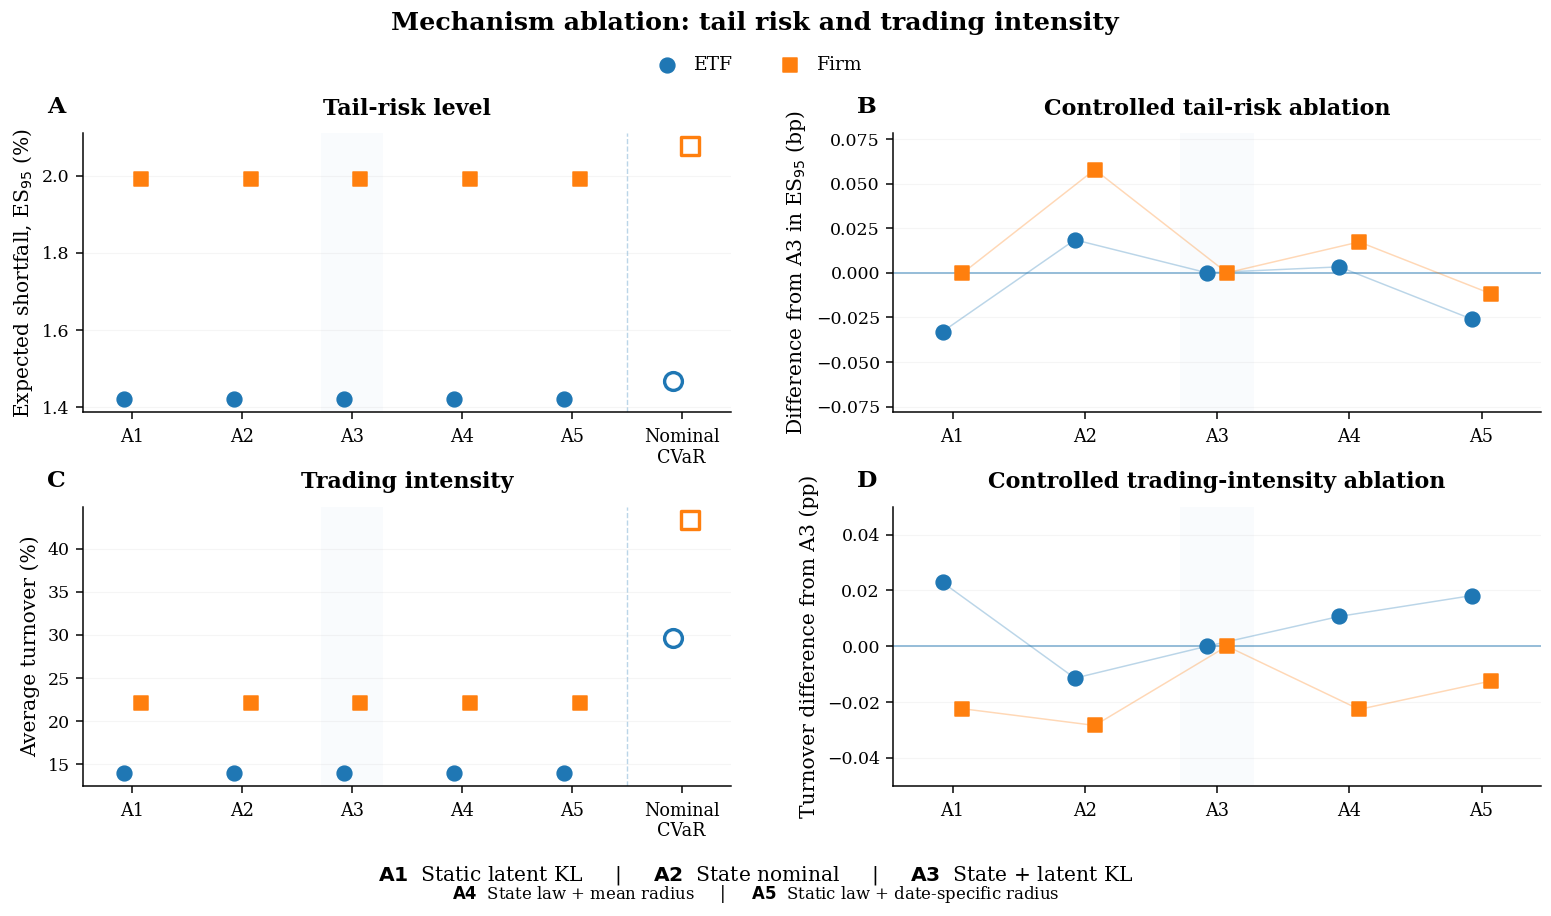

In [3]:
# -------------------------------------------------------------------------
# Figure 2
# -------------------------------------------------------------------------


file = "C:/Users/fredy/Downloads/Section6_Q1PP_Results_V7_FIXED/csv/fig2_empirical_mechanism_ablation.csv"

df = pd.read_csv(file)

required = [
    "Universe",
    "Method",
    "ES95",
    "Turnover",
    "AnnReturn",
    "AnnVol",
    "Sharpe",
    "Sortino",
    "MaxDD",
    "VaR95",
]

expected_methods = [
    "A1_StaticLatentKL",
    "A2_StateNominal",
    "A3_StateLatentKL",
    "A4_StateQ_MeanGamma",
    "A5_StaticQ_DateGamma",
    "NominalCVaR",
]


label_map = {
    "A1_StaticLatentKL": "A1\nStatic latent",
    "A2_StateNominal": "A2\nState nominal",
    "A3_StateLatentKL": "A3\nState + latent KL",
    "A4_StateQ_MeanGamma": "A4\nMean radius",
    "A5_StaticQ_DateGamma": "A5\nStatic law",
    "NominalCVaR": "Nominal\nCVaR",
}

df["Label"] = df["Method"].map(label_map)

df["Method"] = pd.Categorical(df["Method"], categories=expected_methods, ordered=True)

df = df.sort_values(["Universe", "Method"]).reset_index(drop=True)

a3_es = (df[df["Method"] == "A3_StateLatentKL"].set_index("Universe")["ES95"])

a3_turn = (df[df["Method"] == "A3_StateLatentKL"].set_index("Universe")["Turnover"])

df["Delta_ES_vs_A3_bp"] = (df["ES95"] - df["Universe"].map(a3_es).astype(float)) * 10000

df["Delta_Turnover_vs_A3_pp"] = (df["Turnover"] - df["Universe"].map(a3_turn).astype(float)) * 100


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10.5,
        "axes.labelsize": 10.8,
        "axes.titlesize": 11.5,
        "xtick.labelsize": 8.8,
        "ytick.labelsize": 9.2,
        "legend.fontsize": 9.2,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)




# FIGURE — MECHANISM ABLATION

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.0),
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.175,
    top=0.865,
    wspace=0.25,
    hspace=0.34
)

ablation_methods = [
    "A1_StaticLatentKL",
    "A2_StateNominal",
    "A3_StateLatentKL",
    "A4_StateQ_MeanGamma",
    "A5_StaticQ_DateGamma",
]

benchmark_method = "NominalCVaR"

x_all = np.arange(6)
x_abl = np.arange(5)

labels_all = [
    "A1",
    "A2",
    "A3",
    "A4",
    "A5",
    "Nominal\nCVaR"
]

labels_abl = ["A1", "A2", "A3", "A4", "A5"]

universes = ["ETF", "Firm"]

markers = {"ETF": "o", "Firm": "s"}

offsets = {"ETF": -0.075, "Firm": +0.075}

plot_data = {}

for universe in universes:

    g = df[df["Universe"] == universe].copy()

    g["Method"] = pd.Categorical(
        g["Method"],
        categories=ablation_methods + [benchmark_method],
        ordered=True
    )

    g = g.sort_values("Method").reset_index(drop=True)

    assert len(g) == 6
    assert g["Method"].notna().all()

    plot_data[universe] = g


# =========================================================================
# PANEL A — TAIL-RISK LEVEL
# =========================================================================

ax = axes[0, 0]

for universe in universes:

    g = plot_data[universe]

    # A1--A5
    g_abl = g[g["Method"].astype(str).isin(ablation_methods)].copy()

    g_abl["Method"] = g_abl["Method"].astype(str)

    g_abl = (g_abl.set_index("Method").loc[ablation_methods].reset_index())

    y_abl = 100 * g_abl["ES95"].to_numpy()

    ax.scatter(
        x_abl + offsets[universe],
        y_abl,
        marker=markers[universe],
        s=62,
        linewidth=0.8,
        zorder=4,
        label=universe
    )

    # Nominal CVaR — explicitly selected
    g_bench = g[g["Method"].astype(str) == benchmark_method].copy()

    assert len(g_bench) == 1

    y_bench = 100 * float(g_bench["ES95"].iloc[0])

    ax.scatter(
        5 + offsets[universe],
        y_bench,
        marker=markers[universe],
        s=90,
        facecolors="white",
        edgecolors=f"C{universes.index(universe)}",
        linewidth=1.8,
        zorder=7
    )

# A3 focal specification
ax.axvspan(
    1.72,
    2.28,
    alpha=0.025,
    zorder=0
)

# External benchmark separation
ax.axvline(
    4.5,
    linestyle="--",
    linewidth=0.75,
    alpha=0.30,
    zorder=1
)

ax.set_xlim(-0.45, 5.45)

ax.set_xticks(x_all)
ax.set_xticklabels(labels_all)

ax.set_ylabel(r"Expected shortfall, ES$_{95}$ (%)")

ax.set_title(
    "Tail-risk level",
    fontsize=11.8,
    fontweight="semibold",
    pad=10
)

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.65
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL B — CONTROLLED TAIL-RISK ABLATION
# =========================================================================

ax = axes[0, 1]

ax.axhline(
    0,
    linewidth=0.9,
    alpha=0.55,
    zorder=1
)

for universe in universes:

    g = plot_data[universe]

    g_abl = g[g["Method"].astype(str).isin(ablation_methods)].copy()

    g_abl["Method"] = g_abl["Method"].astype(str)

    g_abl = (g_abl.set_index("Method").loc[ablation_methods].reset_index())

    y = g_abl["Delta_ES_vs_A3_bp"].to_numpy()

    ax.plot(
        x_abl + offsets[universe],
        y,
        linewidth=0.8,
        alpha=0.30,
        zorder=2
    )

    ax.scatter(
        x_abl + offsets[universe],
        y,
        marker=markers[universe],
        s=62,
        linewidth=0.8,
        zorder=4
    )

ax.axvspan(
    1.72,
    2.28,
    alpha=0.025,
    zorder=0
)

es_values = (df.loc[df["Method"].astype(str).isin(ablation_methods), "Delta_ES_vs_A3_bp"].astype(float).to_numpy())

es_max = np.nanmax(np.abs(es_values))

es_lim = max(0.05, es_max * 1.35)

ax.set_ylim(-es_lim, es_lim)

ax.set_xlim(-0.45, 4.45)

ax.set_xticks(x_abl)
ax.set_xticklabels(labels_abl)

ax.set_ylabel(r"Difference from A3 in ES$_{95}$ (bp)")

ax.set_title(
    "Controlled tail-risk ablation",
    fontsize=11.8,
    fontweight="semibold",
    pad=10
)

ax.grid(axis="y", alpha=0.12, linewidth=0.65)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL C — TRADING INTENSITY
# =========================================================================

ax = axes[1, 0]

for universe in universes:

    g = plot_data[universe]

    # A1--A5
    g_abl = g[g["Method"].astype(str).isin(ablation_methods)].copy()

    g_abl["Method"] = g_abl["Method"].astype(str)

    g_abl = (g_abl.set_index("Method").loc[ablation_methods].reset_index())

    y_abl = 100 * g_abl["Turnover"].to_numpy()

    ax.scatter(
        x_abl + offsets[universe],
        y_abl,
        marker=markers[universe],
        s=62,
        linewidth=0.8,
        zorder=4
    )

    # Nominal CVaR — explicitly selected
    g_bench = g[g["Method"].astype(str) == benchmark_method].copy()

    assert len(g_bench) == 1

    y_bench = 100 * float(g_bench["Turnover"].iloc[0])

    ax.scatter(
        5 + offsets[universe],
        y_bench,
        marker=markers[universe],
        s=90,
        facecolors="white",
        edgecolors=f"C{universes.index(universe)}",
        linewidth=1.8,
        zorder=7
    )

ax.axvspan(1.72, 2.28, alpha=0.025, zorder=0)

ax.axvline(
    4.5,
    linestyle="--",
    linewidth=0.75,
    alpha=0.30,
    zorder=1
)

ax.set_xlim(-0.45, 5.45)

ax.set_xticks(x_all)
ax.set_xticklabels(labels_all)

ax.set_ylabel("Average turnover (%)")

ax.set_title(
    "Trading intensity",
    fontsize=11.8,
    fontweight="semibold",
    pad=10
)

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.65
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL D — CONTROLLED TRADING-INTENSITY ABLATION
# =========================================================================

ax = axes[1, 1]

ax.axhline(
    0,
    linewidth=0.9,
    alpha=0.55,
    zorder=1
)

for universe in universes:

    g = plot_data[universe]

    g_abl = g[g["Method"].astype(str).isin(ablation_methods)].copy()

    g_abl["Method"] = g_abl["Method"].astype(str)

    g_abl = (g_abl.set_index("Method").loc[ablation_methods].reset_index())

    y = g_abl["Delta_Turnover_vs_A3_pp"].to_numpy()

    ax.plot(
        x_abl + offsets[universe],
        y,
        linewidth=0.8,
        alpha=0.30,
        zorder=2
    )

    ax.scatter(
        x_abl + offsets[universe],
        y,
        marker=markers[universe],
        s=62,
        linewidth=0.8,
        zorder=4
    )

ax.axvspan(1.72, 2.28, alpha=0.025, zorder=0)

turn_values = (df.loc[df["Method"].astype(str).isin(ablation_methods), "Delta_Turnover_vs_A3_pp"].astype(float).to_numpy())

turn_max = np.nanmax(np.abs(turn_values))

turn_lim = max(0.05, turn_max * 1.35)

ax.set_ylim(-turn_lim, turn_lim)

ax.set_xlim(-0.45, 4.45)

ax.set_xticks(x_abl)
ax.set_xticklabels(labels_abl)

ax.set_ylabel("Turnover difference from A3 (pp)")

ax.set_title(
    "Controlled trading-intensity ablation",
    fontsize=11.8,
    fontweight="semibold",
    pad=10
)

ax.grid(axis="y", alpha=0.12, linewidth=0.65)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for ax in axes.flat:

    ax.tick_params(axis="x", labelsize=9.4, pad=5)

    ax.tick_params(axis="y", labelsize=9.3)


# =========================================================================
# PANEL LETTERS
# =========================================================================

for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):

    ax.text(
        -0.055,
        1.055,
        letter,
        transform=ax.transAxes,
        fontsize=12.5,
        fontweight="bold",
        ha="left",
        va="bottom"
    )

fig.suptitle(
    "Mechanism ablation: tail risk and trading intensity",
    fontsize=13.5,
    fontweight="semibold",
    y=0.995
)

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    frameon=False,
    fontsize=10.0,
    handletextpad=0.45,
    columnspacing=2.0
)

fig.text(
    0.5,
    0.080,
    r"$\bf{A1}$  Static latent KL"
    r"     $\vert$     "
    r"$\bf{A2}$  State nominal"
    r"     $\vert$     "
    r"$\bf{A3}$  State + latent KL",
    ha="center",
    va="center",
    fontsize=10.8
)

fig.text(
    0.5,
    0.060,
    r"$\bf{A4}$  State law + mean radius"
    r"     $\vert$     "
    r"$\bf{A5}$  Static law + date-specific radius",
    ha="center",
    va="center",
    fontsize=8.8
)


plt.show()


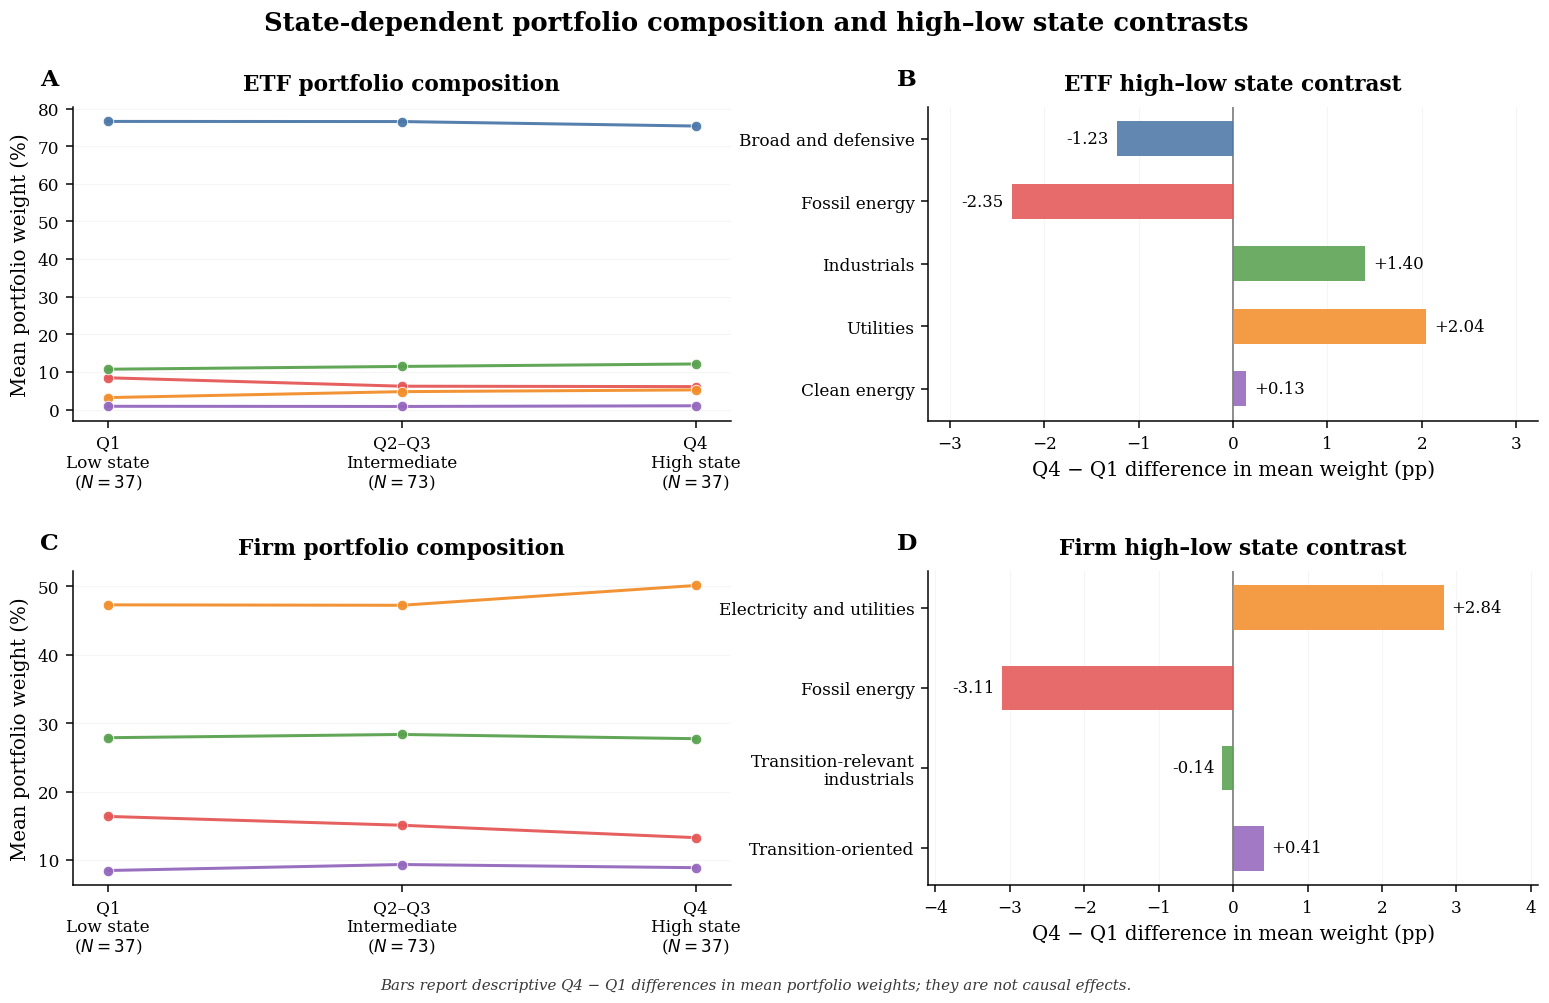

In [4]:
# -------------------------------------------------------------------------
# Figure 3
# -------------------------------------------------------------------------

file = (
    "C:/Users/fredy/Downloads/Section6_Q1PP_Results_V7_FIXED/"
    "csv/fig3_state_dependent_reallocation.csv"
)

df = pd.read_csv(file)

required = [
    "Universe",
    "Date",
    "StateGroup",
    "Block",
    "Weight",
]

missing = [x for x in required if x not in df.columns]

df = df[required].copy()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")

df = df.dropna(subset=["Universe", "Date", "StateGroup", "Block", "Weight"]).copy()

df = (df.sort_values(["Universe", "Date", "Block"]).reset_index(drop=True))



expected_universes = {"ETF", "Firm"}

observed_universes = set(df["Universe"].unique())

state_order = ["Q1", "Q2-Q3", "Q4"]

unexpected_states = (set(df["StateGroup"].unique()) - set(state_order))


weight_sums = (
    df.groupby(["Universe", "Date"])["Weight"]
      .sum()
)

max_sum_error = float(
    np.max(np.abs(weight_sums.to_numpy() - 1.0))
)

state_counts = (
    df.groupby(["Universe", "StateGroup"])["Date"]
      .nunique()
      .unstack("StateGroup")
      .reindex(columns=state_order)
)

etf_blocks = [
    "Broad and defensive",
    "Fossil energy",
    "Industrials",
    "Utilities",
    "Clean energy",
]

firm_blocks = [
    "Electricity and utilities",
    "Fossil energy",
    "Transition-relevant industrials",
    "Transition-oriented"]


# -----------------------------------------------------------------------------
# Validate blocks.
# -----------------------------------------------------------------------------

observed_etf_blocks = set(df.loc[df["Universe"] == "ETF","Block"].unique())

observed_firm_blocks = set(df.loc[df["Universe"] == "Firm", "Block"].unique())


summary = (
    df.groupby(
        ["Universe", "StateGroup", "Block"],
        observed=True
    )
    .agg(
        Mean=("Weight", "mean"),
        Median=("Weight", "median"),
        SD=("Weight", "std"),
        Q25=("Weight", lambda x: x.quantile(0.25)),
        Q75=("Weight", lambda x: x.quantile(0.75)),
        N=("Weight", "size"),
    )
    .reset_index()
)

mean_table = (
    summary
    .pivot_table(
        index=["Universe", "Block"],
        columns="StateGroup",
        values="Mean",
        observed=True
    )
    .reset_index()
)

mean_table["Delta_Q4_Q1"] = (mean_table["Q4"] - mean_table["Q1"])

mean_table["Delta_Q4_Q1_pp"] = (100.0 * mean_table["Delta_Q4_Q1"])

delta_sum_check = (
    mean_table
    .groupby("Universe")["Delta_Q4_Q1"]
    .sum()
)

etf = (summary[summary["Universe"] == "ETF"].copy())

etf["Block"] = pd.Categorical(
    etf["Block"],
    categories=etf_blocks,
    ordered=True
)

etf["StateGroup"] = pd.Categorical(
    etf["StateGroup"],
    categories=state_order,
    ordered=True
)

etf = etf.sort_values(["Block", "StateGroup"])


etf_delta = (mean_table[mean_table["Universe"] == "ETF"].copy())

etf_delta["Block"] = pd.Categorical(
    etf_delta["Block"],
    categories=etf_blocks,
    ordered=True
)

etf_delta = etf_delta.sort_values("Block")


firm = (summary[summary["Universe"] == "Firm"].copy())

firm["Block"] = pd.Categorical(
    firm["Block"],
    categories=firm_blocks,
    ordered=True)

firm["StateGroup"] = pd.Categorical(
    firm["StateGroup"],
    categories=state_order,
    ordered=True)

firm = firm.sort_values(["Block", "StateGroup"])


firm_delta = (mean_table[mean_table["Universe"] == "Firm"].copy())

firm_delta["Block"] = pd.Categorical(
    firm_delta["Block"],
    categories=firm_blocks,
    ordered=True
)

firm_delta = firm_delta.sort_values("Block")




plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10.0,
        "axes.labelsize": 10.5,
        "axes.titlesize": 11.5,
        "xtick.labelsize": 9.0,
        "ytick.labelsize": 9.0,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


block_colors = {
    # ETF
    "Broad and defensive": "#4C78A8",
    "Fossil energy": "#E45756",
    "Industrials": "#59A14F",
    "Utilities": "#F28E2B",
    "Clean energy": "#9467BD",

    # Firm
    "Electricity and utilities": "#F28E2B",
    "Transition-relevant industrials": "#59A14F",
    "Transition-oriented": "#9467BD",
}


display_labels = {
    "Broad and defensive":
        "Broad and defensive",

    "Fossil energy":
        "Fossil energy",

    "Industrials":
        "Industrials",

    "Utilities":
        "Utilities",

    "Clean energy":
        "Clean energy",

    "Electricity and utilities":
        "Electricity and utilities",

    "Transition-relevant industrials":
        "Transition-relevant\nindustrials",

    "Transition-oriented":
        "Transition-oriented",
}

state_x = np.array([0, 1, 2])

etf_counts = (state_counts.loc["ETF", state_order].astype(int))

firm_counts = (state_counts.loc["Firm", state_order].astype(int))

etf_state_labels = [
    f"Q1\nLow state\n($N={etf_counts['Q1']}$)",
    f"Q2–Q3\nIntermediate\n($N={etf_counts['Q2-Q3']}$)",
    f"Q4\nHigh state\n($N={etf_counts['Q4']}$)"]

firm_state_labels = [
    f"Q1\nLow state\n($N={firm_counts['Q1']}$)",
    f"Q2–Q3\nIntermediate\n($N={firm_counts['Q2-Q3']}$)",
    f"Q4\nHigh state\n($N={firm_counts['Q4']}$)"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.2, 8.0),
    gridspec_kw={"width_ratios": [1.24, 1.15]},
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.085,
    right=0.975,
    bottom=0.175,
    top=0.895,
    wspace=0.31,
    hspace=0.48
)


# =============================================================================
# PANEL A — ETF PORTFOLIO COMPOSITION
# =============================================================================

ax = axes[0, 0]

for block in etf_blocks:

    g = (etf[etf["Block"].astype(str) == block].copy())

    g["StateGroup"] = pd.Categorical(
        g["StateGroup"].astype(str),
        categories=state_order,
        ordered=True
    )

    g = g.sort_values("StateGroup")

    y = (100.0 * g["Mean"].to_numpy())

    ax.plot(
        state_x,
        y,
        color=block_colors[block],
        marker="o",
        markersize=5.6,
        markerfacecolor=block_colors[block],
        markeredgecolor="white",
        markeredgewidth=0.45,
        linewidth=1.60,
        alpha=0.95,
        zorder=3
    )


ax.set_xlim(-0.12, 2.12)

ax.set_xticks(state_x)

ax.set_xticklabels(
    etf_state_labels,
    linespacing=1.15
)

ax.set_ylabel("Mean portfolio weight (%)")

ax.set_title(
    "ETF portfolio composition",
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.65,
    zorder=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =============================================================================
# PANEL B — ETF HIGH–LOW STATE CONTRAST
# =============================================================================

ax = axes[0, 1]

g = etf_delta.copy()

g["Block"] = pd.Categorical(
    g["Block"].astype(str),
    categories=etf_blocks,
    ordered=True
)

g = g.sort_values("Block")

ypos = np.arange(len(g))

delta = (g["Delta_Q4_Q1_pp"].to_numpy())

bar_colors = [block_colors[str(block)] for block in g["Block"]]


ax.axvline(
    0,
    color="0.35",
    linewidth=0.9,
    alpha=0.80,
    zorder=1
)

ax.barh(
    ypos,
    delta,
    height=0.56,
    color=bar_colors,
    alpha=0.88,
    edgecolor="none",
    zorder=3
)

ax.set_yticks(ypos)

ax.set_yticklabels(
    [display_labels[str(block)] for block in g["Block"]],
    fontsize=9.0
)

ax.invert_yaxis()


limit_etf = max(3.2, np.nanmax(np.abs(delta)) * 1.38)

ax.set_xlim(-limit_etf, limit_etf)


for i, value in enumerate(delta):

    if value >= 0:

        ax.text(
            value + 0.09,
            i,
            f"+{value:.2f}",
            ha="left",
            va="center",
            fontsize=8.8
        )

    else:

        ax.text(
            value - 0.09,
            i,
            f"{value:.2f}",
            ha="right",
            va="center",
            fontsize=8.8
        )


ax.set_xlabel("Q4 − Q1 difference in mean weight (pp)")

ax.set_title(
    "ETF high–low state contrast",
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="x",
    alpha=0.12,
    linewidth=0.65,
    zorder=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =============================================================================
# PANEL C — FIRM PORTFOLIO COMPOSITION
# =============================================================================

ax = axes[1, 0]

for block in firm_blocks:

    g = (firm[firm["Block"].astype(str) == block].copy())

    g["StateGroup"] = pd.Categorical(
        g["StateGroup"].astype(str),
        categories=state_order,
        ordered=True
    )

    g = g.sort_values("StateGroup")

    y = (100.0 * g["Mean"].to_numpy())

    ax.plot(
        state_x,
        y,
        color=block_colors[block],
        marker="o",
        markersize=5.6,
        markerfacecolor=block_colors[block],
        markeredgecolor="white",
        markeredgewidth=0.45,
        linewidth=1.60,
        alpha=0.95,
        zorder=3
    )


ax.set_xlim(-0.12, 2.12)

ax.set_xticks(state_x)

ax.set_xticklabels(
    firm_state_labels,
    linespacing=1.15
)

ax.set_ylabel("Mean portfolio weight (%)")

ax.set_title(
    "Firm portfolio composition",
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.65,
    zorder=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =============================================================================
# PANEL D — FIRM HIGH–LOW STATE CONTRAST
# =============================================================================

ax = axes[1, 1]

g = firm_delta.copy()

g["Block"] = pd.Categorical(
    g["Block"].astype(str),
    categories=firm_blocks,
    ordered=True
)

g = g.sort_values("Block")

ypos = np.arange(len(g))

delta = (g["Delta_Q4_Q1_pp"].to_numpy())

bar_colors = [block_colors[str(block)] for block in g["Block"]]


ax.axvline(
    0,
    color="0.35",
    linewidth=0.9,
    alpha=0.80,
    zorder=1
)

ax.barh(
    ypos,
    delta,
    height=0.56,
    color=bar_colors,
    alpha=0.88,
    edgecolor="none",
    zorder=3
)

ax.set_yticks(ypos)

ax.set_yticklabels(
    [display_labels[str(block)] for block in g["Block"]],
    fontsize=8.9,
    linespacing=1.05
)

ax.invert_yaxis()


limit_firm = max(3.8, np.nanmax(np.abs(delta)) * 1.32)

ax.set_xlim(-limit_firm, limit_firm)


for i, value in enumerate(delta):

    if value >= 0:

        ax.text(
            value + 0.10,
            i,
            f"+{value:.2f}",
            ha="left",
            va="center",
            fontsize=8.8
        )

    else:

        ax.text(
            value - 0.10,
            i,
            f"{value:.2f}",
            ha="right",
            va="center",
            fontsize=8.8
        )


ax.set_xlabel("Q4 − Q1 difference in mean weight (pp)")

ax.set_title(
    "Firm high–low state contrast",
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="x",
    alpha=0.12,
    linewidth=0.65,
    zorder=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for ax in axes.flat:

    ax.tick_params(axis="x", labelsize=9.0, pad=4)

    ax.tick_params(axis="y", labelsize=9.0)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):

    ax.text(
        -0.050,
        1.055,
        letter,
        transform=ax.transAxes,
        fontsize=12.5,
        fontweight="bold",
        ha="left",
        va="bottom"
    )

fig.suptitle(
    "State-dependent portfolio composition and high–low state contrasts",
    fontsize=13.8,
    fontweight="semibold",
    y=0.985
)


fig.text(
    0.5,
    0.082,
    (
        "Bars report descriptive Q4 − Q1 differences in mean portfolio "
        "weights; they are not causal effects."
    ),
    ha="center",
    va="center",
    fontsize=8.0,
    style="italic",
    alpha=0.78
)

plt.show()


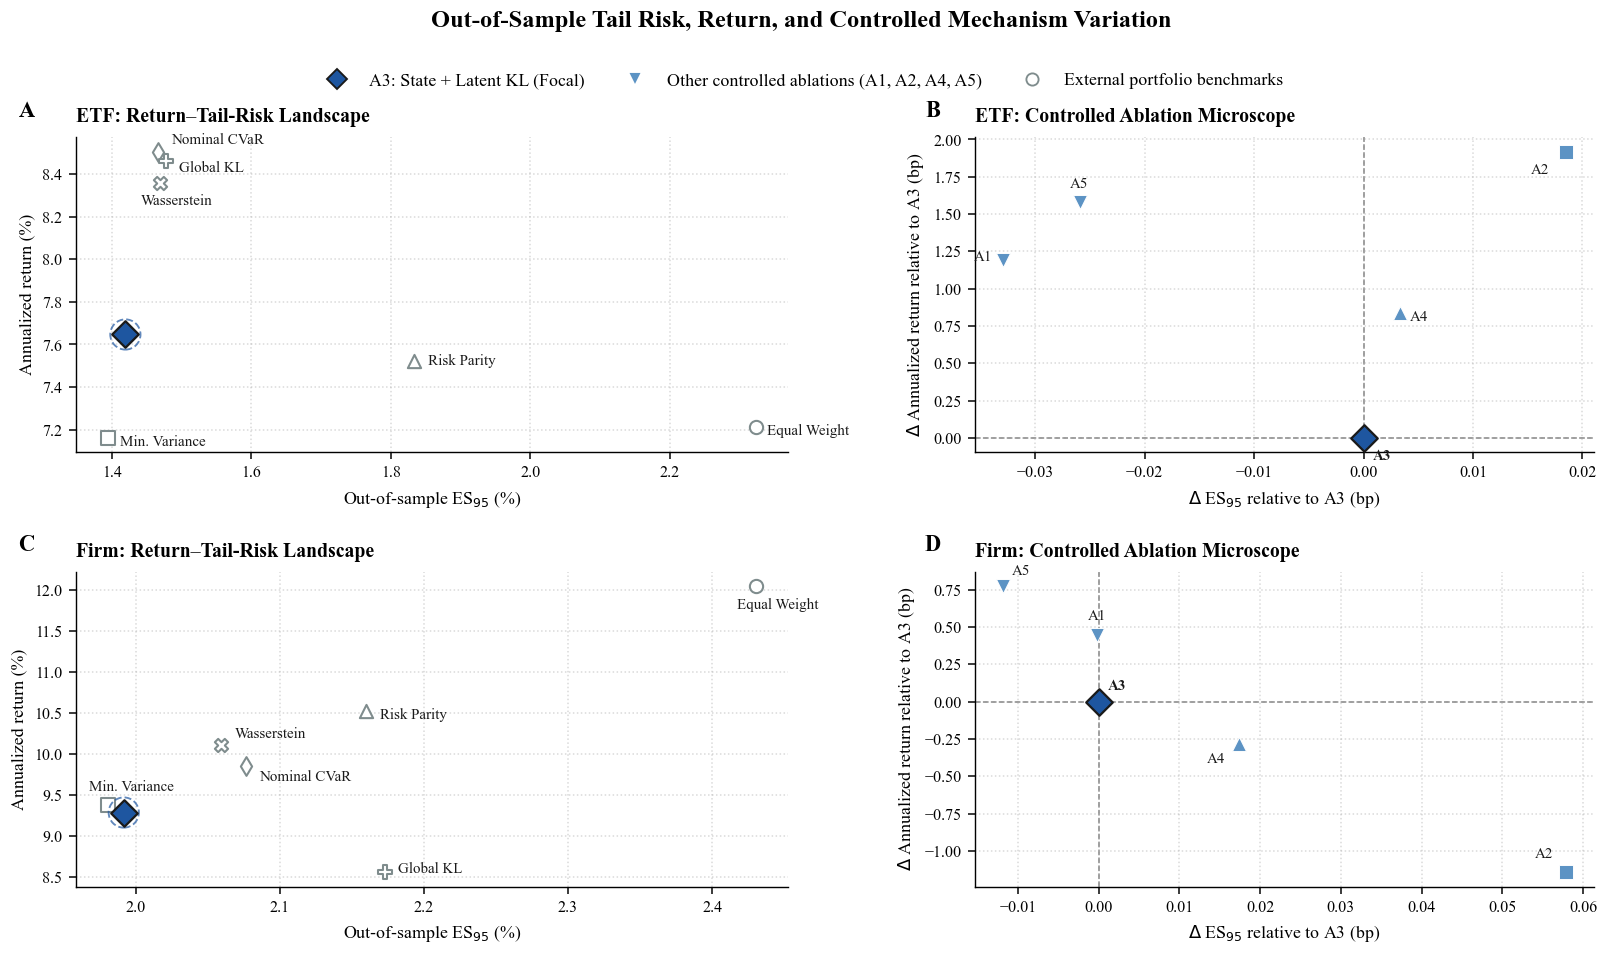

In [5]:
# -------------------------------------------------------------------------
# Figure 4
# -------------------------------------------------------------------------


file_path = "C:/Users/fredy/Downloads/Section6_Q1PP_Results_V7_FIXED/csv/fig4_tail_risk_performance_frontier.csv"

df = pd.read_csv(file_path)

ablation_methods = [
    "A1_StaticLatentKL",
    "A2_StateNominal",
    "A3_StateLatentKL",
    "A4_StateQ_MeanGamma",
    "A5_StaticQ_DateGamma"
]

benchmark_methods = ["EqualWeight", "MinVariance", "RiskParity", "NominalCVaR", "GlobalKL", "Wasserstein"]

short_labels = {
    "A1_StaticLatentKL": "A1",
    "A2_StateNominal": "A2",
    "A3_StateLatentKL": "A3",
    "A4_StateQ_MeanGamma": "A4",
    "A5_StaticQ_DateGamma": "A5",
    "EqualWeight": "Equal Weight",
    "MinVariance": "Min. Variance",
    "RiskParity": "Risk Parity",
    "NominalCVaR": "Nominal CVaR",
    "GlobalKL": "Global KL",
    "Wasserstein": "Wasserstein"
}

# Calcul des deltas (remise à l'échelle claire en bp pour les 2 axes)
contrast_rows = []
for universe in ["ETF", "Firm"]:
    gu = df[df["Universe"] == universe].copy()
    a3 = gu[gu["Method"] == "A3_StateLatentKL"].iloc[0]

    for method in ablation_methods:
        r = gu[gu["Method"] == method].iloc[0]
        contrast_rows.append({
            "Universe": universe,
            "Method": method,
            # Conversion propre : 1 bp = 0.0001
            "Delta_ES_bp": (float(r["ES95"]) - float(a3["ES95"])) * 10000,
            "Delta_Return_bp": (float(r["AnnReturn"]) - float(a3["AnnReturn"])) * 10000,
        })

contrast = pd.DataFrame(contrast_rows)


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 9.5,
    "axes.labelsize": 9.5,
    "axes.titlesize": 10.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.75,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

DARK = "#1A1A1A"
MID_GREY = "#7F8C8D"
BLUE = "#1E56A0"
C_ABLATION = "#5C93C4"

ablation_colors = {
    "A1_StaticLatentKL": C_ABLATION,
    "A2_StateNominal": C_ABLATION,
    "A3_StateLatentKL": BLUE,
    "A4_StateQ_MeanGamma": C_ABLATION,
    "A5_StaticQ_DateGamma": C_ABLATION
}

ablation_markers = {
    "A1_StaticLatentKL": "v",
    "A2_StateNominal": "s",
    "A3_StateLatentKL": "D",
    "A4_StateQ_MeanGamma": "^",
    "A5_StaticQ_DateGamma": "v"
}

benchmark_markers = {
    "EqualWeight": "o",
    "MinVariance": "s",
    "RiskParity": "^",
    "NominalCVaR": "d",
    "GlobalKL": "P",
    "Wasserstein": "X"
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12.5, 7.5),
    gridspec_kw={"width_ratios": [1.15, 1.0], "height_ratios": [1.0, 1.0]}
)

plt.subplots_adjust(
    left=0.07, right=0.97,
    bottom=0.12, top=0.86,
    wspace=0.28, hspace=0.38
)

# =========================================================================
# PANNEAU A — ETF: FULL RETURN–TAIL-RISK LANDSCAPE
# =========================================================================
ax = axes[0, 0]
g = df[df["Universe"] == "ETF"].copy()

for method in benchmark_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = 100 * float(r["ES95"]), 100 * float(r["AnnReturn"])
    ax.scatter(x, y, marker=benchmark_markers[method], s=50,
               facecolors="white", edgecolors=MID_GREY, linewidth=1.1, zorder=3)

    # Re-positionnement intelligent pour éviter tout chevauchement
    offsets_etf = {
        "EqualWeight": (6, -2),
        "MinVariance": (6.3, -2.),
        "RiskParity": (7, 0),
        "NominalCVaR": (7, 6),
        "GlobalKL": (7, -4),
        "Wasserstein": (-10, -10)
    }
    dx, dy = offsets_etf[method]
    ax.annotate(short_labels[method], xy=(x, y), xytext=(dx, dy),
                textcoords="offset points", fontsize=8.1, color=DARK, va="center")

for method in ablation_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = 100 * float(r["ES95"]), 100 * float(r["AnnReturn"])
    if method == "A3_StateLatentKL":
        ax.scatter(x, y, marker=ablation_markers[method], s=100, color=BLUE,
                   edgecolor=DARK, linewidth=1.2, zorder=6)
        # Ring d'accentuation parfaitement centré
        ax.scatter(x, y, s=260, facecolors="none", edgecolors=BLUE,
                   linewidth=1.0, linestyle="--", alpha=0.7, zorder=5)
    else:
        ax.scatter(x, y, marker=ablation_markers[method], s=45, color=C_ABLATION,
                   edgecolor="white", linewidth=0.5, zorder=4)

ax.set_xlabel(r"Out-of-sample ES$_{95}$ (%)")
ax.set_ylabel("Annualized return (%)")
ax.set_title("ETF: Return–Tail-Risk Landscape", fontweight="bold", pad=8, loc="left")
ax.grid(True, ls=":", color="0.7", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================================
# PANNEAU B — ETF: CONTROLLED ABLATION MICROSCOPE
# =========================================================================
ax = axes[0, 1]
g = contrast[contrast["Universe"] == "ETF"].copy()

ax.axhline(0, color="0.5", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="0.5", lw=0.8, ls="--", zorder=1)

for method in ablation_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = float(r["Delta_ES_bp"]), float(r["Delta_Return_bp"])
    if method == "A3_StateLatentKL":
        ax.scatter(x, y, marker=ablation_markers[method], s=100, color=BLUE,
                   edgecolor=DARK, linewidth=1.2, zorder=6)
    else:
        ax.scatter(x, y, marker=ablation_markers[method], s=55, color=C_ABLATION,
                   edgecolor="white", linewidth=0.5, zorder=5)

    annotation_offsets = {
        "A1_StaticLatentKL": (-10.5, 1.5),
        "A2_StateNominal": (-14, -10),
        "A3_StateLatentKL": (10, -10),
        "A4_StateQ_MeanGamma": (10, -2),
        "A5_StaticQ_DateGamma": (0, 10)
    }
    dx, dy = annotation_offsets[method]
    ax.annotate(short_labels[method], xy=(x, y), xytext=(dx, dy),
                textcoords="offset points", fontsize=8,
                fontweight="bold" if method == "A3_StateLatentKL" else "normal",
                color=DARK, ha="center", va="center")

ax.set_xlabel(r"$\Delta$ ES$_{95}$ relative to A3 (bp)")
ax.set_ylabel(r"$\Delta$ Annualized return relative to A3 (bp)")
ax.set_title("ETF: Controlled Ablation Microscope", fontweight="bold", pad=8, loc="left")
ax.grid(True, ls=":", color="0.7", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================================
# PANNEAU C — FIRM: FULL RETURN–TAIL-RISK LANDSCAPE
# =========================================================================
ax = axes[1, 0]
g = df[df["Universe"] == "Firm"].copy()

for method in benchmark_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = 100 * float(r["ES95"]), 100 * float(r["AnnReturn"])
    ax.scatter(x, y, marker=benchmark_markers[method], s=50,
               facecolors="white", edgecolors=MID_GREY, linewidth=1.1, zorder=3)

    offsets_firm = {
        "EqualWeight": (-10, -10),
        "MinVariance": (-10, 10),
        "RiskParity": (7, -2),
        "NominalCVaR": (7, -6),
        "GlobalKL": (7, 2),
        "Wasserstein": (7, 6)
    }
    dx, dy = offsets_firm[method]
    ax.annotate(short_labels[method], xy=(x, y), xytext=(dx, dy),
                textcoords="offset points", fontsize=8., color=DARK, va="center")

for method in ablation_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = 100 * float(r["ES95"]), 100 * float(r["AnnReturn"])
    if method == "A3_StateLatentKL":
        ax.scatter(x, y, marker=ablation_markers[method], s=100, color=BLUE,
                   edgecolor=DARK, linewidth=1.2, zorder=6)
        ax.scatter(x, y, s=260, facecolors="none", edgecolors=BLUE,
                   linewidth=1.0, linestyle="--", alpha=0.7, zorder=5)
    else:
        ax.scatter(x, y, marker=ablation_markers[method], s=45, color=C_ABLATION,
                   edgecolor="white", linewidth=0.5, zorder=4)

ax.set_xlabel(r"Out-of-sample ES$_{95}$ (%)")
ax.set_ylabel("Annualized return (%)")
ax.set_title("Firm: Return–Tail-Risk Landscape", fontweight="bold", pad=8, loc="left")
ax.grid(True, ls=":", color="0.7", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================================
# PANNEAU D — FIRM: CONTROLLED ABLATION MICROSCOPE
# =========================================================================
ax = axes[1, 1]
g = contrast[contrast["Universe"] == "Firm"].copy()

ax.axhline(0, color="0.5", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="0.5", lw=0.8, ls="--", zorder=1)

for method in ablation_methods:
    r = g[g["Method"] == method].iloc[0]
    x, y = float(r["Delta_ES_bp"]), float(r["Delta_Return_bp"])
    if method == "A3_StateLatentKL":
        ax.scatter(x, y, marker=ablation_markers[method], s=100, color=BLUE,
                   edgecolor=DARK, linewidth=1.2, zorder=6)
    else:
        ax.scatter(x, y, marker=ablation_markers[method], s=55, color=C_ABLATION,
                   edgecolor="white", linewidth=0.5, zorder=5)

    annotation_offsets = {
        "A1_StaticLatentKL": (0, 10),
        "A2_StateNominal": (-12, 10),
        "A3_StateLatentKL": (10, 8),
        "A4_StateQ_MeanGamma": (-12, -8),
        "A5_StaticQ_DateGamma": (10, 8)
    }
    dx, dy = annotation_offsets[method]
    ax.annotate(short_labels[method], xy=(x, y), xytext=(dx, dy),
                textcoords="offset points", fontsize=8,
                fontweight="bold" if method == "A3_StateLatentKL" else "normal",
                color=DARK, ha="center", va="center")

ax.set_xlabel(r"$\Delta$ ES$_{95}$ relative to A3 (bp)")
ax.set_ylabel(r"$\Delta$ Annualized return relative to A3 (bp)")
ax.set_title("Firm: Controlled Ablation Microscope", fontweight="bold", pad=8, loc="left")
ax.grid(True, ls=":", color="0.7", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================================
# ANNOTATIONS ET LEGENDE GLOBALE
# =========================================================================
for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):
    ax.text(-0.08, 1.05, letter, transform=ax.transAxes,
            fontsize=12, fontweight="bold", ha="left", va="bottom")

legend_handles = [
    Line2D([0], [0], marker="D", linestyle="none", markerfacecolor=BLUE,
           markeredgecolor=DARK, markersize=7.5, label="A3: State + Latent KL (Focal)"),
    Line2D([0], [0], marker="v", linestyle="none", markerfacecolor=C_ABLATION,
           markeredgecolor="white", markersize=7.0, label="Other controlled ablations (A1, A2, A4, A5)"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white",
           markeredgecolor=MID_GREY, markersize=6.5, label="External portfolio benchmarks")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    columnspacing=1.8
)

fig.suptitle(
    "Out-of-Sample Tail Risk, Return, and Controlled Mechanism Variation",
    fontsize=13, fontweight="bold", y=0.985
)

plt.show()


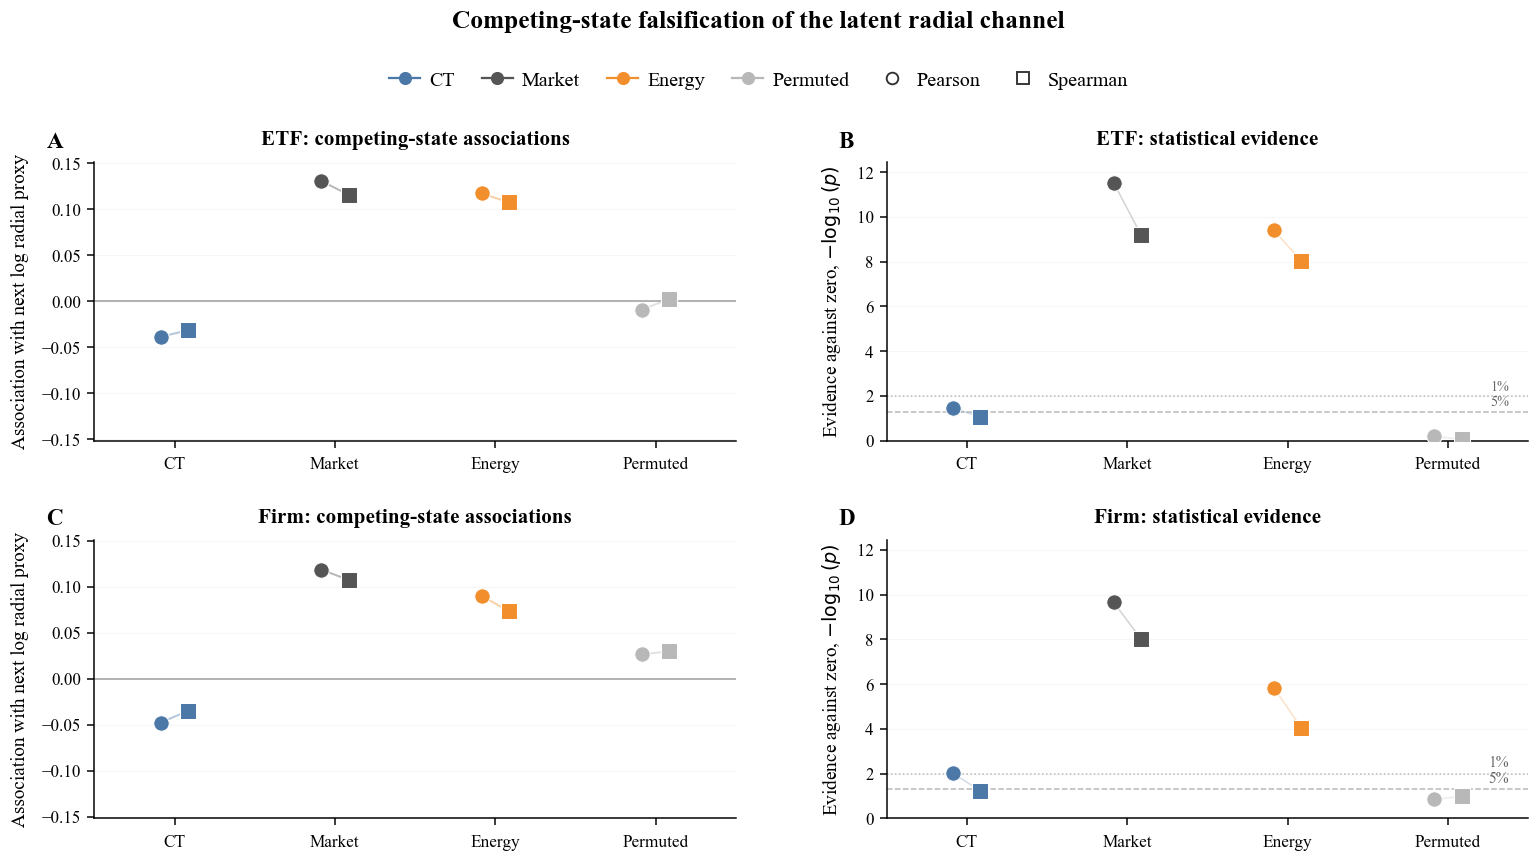

In [6]:
# -------------------------------------------------------------------------
# Figure 5
# -------------------------------------------------------------------------

file_path = "C:/Users/fredy/Downloads/Section6_Q1PP_Results_V7_FIXED/csv/fig5_competing_state_placebos.csv"

df = pd.read_csv(file_path)

required = [
    "Universe",
    "State",
    "Pearson",
    "Pearson_p",
    "Spearman",
    "Spearman_p",
    "N"
]

state_order = ["CT", "Market", "Energy", "Permuted"]

state_labels = ["CT", "Market", "Energy", "Permuted"]

df["State"] = pd.Categorical(
    df["State"],
    categories=state_order,
    ordered=True
)

df = df.sort_values(["Universe", "State"]).reset_index(drop=True)

# =========================================================================
# COLORS
#
# Coherent with previous figures:
# blue   = focal structural object
# orange = energy-related object
# greys  = competing / placebo states
# =========================================================================

BLUE = "#4C78A8"
ORANGE = "#F28E2B"
DARK_GREY = "#555555"
LIGHT_GREY = "#B8B8B8"
VERY_LIGHT_GREY = "#E6E6E6"
TEXT = "#303030"

state_colors = {
    "CT": BLUE,
    "Market": DARK_GREY,
    "Energy": ORANGE,
    "Permuted": LIGHT_GREY
}

# =========================================================================
# PREPARE LONG-FORM CORRELATION DATA
# =========================================================================

rows = []

for _, r in df.iterrows():

    rows.append(
        {
            "Universe": r["Universe"],
            "State": str(r["State"]),
            "Statistic": "Pearson",
            "Correlation": float(r["Pearson"]),
            "p_value": float(r["Pearson_p"]),
            "N": int(r["N"])
        }
    )

    rows.append(
        {
            "Universe": r["Universe"],
            "State": str(r["State"]),
            "Statistic": "Spearman",
            "Correlation": float(r["Spearman"]),
            "p_value": float(r["Spearman_p"]),
            "N": int(r["N"])
        }
    )

long = pd.DataFrame(rows)

long["minus_log10_p"] = -np.log10(np.clip(long["p_value"].to_numpy(),1e-300,1.0))


# =========================================================================
# TYPOGRAPHY
# =========================================================================

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10.0,
        "axes.labelsize": 10.3,
        "axes.titlesize": 11.5,
        "xtick.labelsize": 9.2,
        "ytick.labelsize": 9.0,
        "legend.fontsize": 8.6,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    }
)

# =========================================================================
# FIGURE
# =========================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.15),
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.090,
    right=0.975,
    bottom=0.155,
    top=0.835,
    wspace=0.235,
    hspace=0.355
)

x = np.arange(len(state_order))

pearson_offset = -0.085
spearman_offset = +0.085

# =========================================================================
# COMMON AXIS LIMITS
# =========================================================================

corr_max = np.nanmax(np.abs(long["Correlation"].to_numpy()))

corr_lim = max(0.15, corr_max * 1.16)

p_max = np.nanmax(long["minus_log10_p"].to_numpy())

p_lim = max(3.0, p_max * 1.08)

p05 = -np.log10(0.05)
p01 = -np.log10(0.01)


# =========================================================================
# PANEL A — ETF: COMPETING-STATE ASSOCIATIONS
# =========================================================================

ax = axes[0, 0]

g = (long.loc[long["Universe"] == "ETF"].copy())

ax.axhline(
    0,
    color="#707070",
    linewidth=0.85,
    alpha=0.65,
    zorder=1
)

for i, state in enumerate(state_order):

    gs = g.loc[g["State"] == state]

    pearson = gs.loc[gs["Statistic"] == "Pearson"].iloc[0]

    spearman = gs.loc[gs["Statistic"] == "Spearman"].iloc[0]

    # Connector: shows robustness across correlation measures
    ax.plot(
        [i + pearson_offset, i + spearman_offset],
        [pearson["Correlation"], spearman["Correlation"]],
        color=state_colors[state],
        linewidth=1.05,
        alpha=0.42,
        zorder=2
    )

    ax.scatter(
        i + pearson_offset,
        pearson["Correlation"],
        s=68,
        marker="o",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

    ax.scatter(
        i + spearman_offset,
        spearman["Correlation"],
        s=66,
        marker="s",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

ax.set_xlim(-0.50, 3.50)
ax.set_ylim(-corr_lim, corr_lim)

ax.set_xticks(x)
ax.set_xticklabels(state_labels)

ax.set_ylabel("Association with next log radial proxy", labelpad=7)

ax.set_title(
    "ETF: competing-state associations",
    fontsize=11.3,
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.11,
    linewidth=0.60
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL B — ETF: STATISTICAL EVIDENCE
# =========================================================================

ax = axes[0, 1]

g = (long.loc[long["Universe"] == "ETF"].copy())

# Conventional significance thresholds
ax.axhline(
    p05,
    color="#888888",
    linestyle="--",
    linewidth=0.80,
    alpha=0.60,
    zorder=1
)

ax.axhline(
    p01,
    color="#888888",
    linestyle=":",
    linewidth=0.80,
    alpha=0.60,
    zorder=1
)

for i, state in enumerate(state_order):

    gs = g.loc[g["State"] == state]

    pearson = gs.loc[gs["Statistic"] == "Pearson"].iloc[0]

    spearman = gs.loc[gs["Statistic"] == "Spearman"].iloc[0]

    # Small connector for Pearson/Spearman pair
    ax.plot(
        [i + pearson_offset, i + spearman_offset],
        [pearson["minus_log10_p"], spearman["minus_log10_p"]],
        color=state_colors[state],
        linewidth=0.85,
        alpha=0.25,
        zorder=2
    )

    ax.scatter(
        i + pearson_offset,
        pearson["minus_log10_p"],
        s=68,
        marker="o",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

    ax.scatter(
        i + spearman_offset,
        spearman["minus_log10_p"],
        s=66,
        marker="s",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

# Threshold labels INSIDE the panel
ax.text(
    3.38,
    p05 + 0.12,
    "5%",
    ha="right",
    va="bottom",
    fontsize=7.6,
    color="#666666"
)

ax.text(
    3.38,
    p01 + 0.12,
    "1%",
    ha="right",
    va="bottom",
    fontsize=7.6,
    color="#666666"
)

ax.set_xlim(-0.50, 3.50)
ax.set_ylim(0, p_lim)

ax.set_xticks(x)
ax.set_xticklabels(state_labels)

ax.set_ylabel(
    r"Evidence against zero, $-\log_{10}(p)$",
    labelpad=7
)

ax.set_title(
    "ETF: statistical evidence",
    fontsize=11.3,
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.11,
    linewidth=0.60
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL C — FIRM: COMPETING-STATE ASSOCIATIONS
# =========================================================================

ax = axes[1, 0]

g = (long.loc[long["Universe"] == "Firm"].copy())

ax.axhline(
    0,
    color="#707070",
    linewidth=0.85,
    alpha=0.65,
    zorder=1
)

for i, state in enumerate(state_order):

    gs = g.loc[g["State"] == state]

    pearson = gs.loc[gs["Statistic"] == "Pearson"].iloc[0]

    spearman = gs.loc[gs["Statistic"] == "Spearman"].iloc[0]

    ax.plot(
        [i + pearson_offset, i + spearman_offset],
        [pearson["Correlation"], spearman["Correlation"]],
        color=state_colors[state],
        linewidth=1.05,
        alpha=0.42,
        zorder=2
    )

    ax.scatter(
        i + pearson_offset,
        pearson["Correlation"],
        s=68,
        marker="o",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

    ax.scatter(
        i + spearman_offset,
        spearman["Correlation"],
        s=66,
        marker="s",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

ax.set_xlim(-0.50, 3.50)
ax.set_ylim(-corr_lim, corr_lim)

ax.set_xticks(x)
ax.set_xticklabels(state_labels)

ax.set_ylabel(
    "Association with next log radial proxy",
    labelpad=7
)

ax.set_title(
    "Firm: competing-state associations",
    fontsize=11.3,
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.11,
    linewidth=0.60
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# PANEL D — FIRM: STATISTICAL EVIDENCE
# =========================================================================

ax = axes[1, 1]

g = (long.loc[long["Universe"] == "Firm"].copy())

ax.axhline(
    p05,
    color="#888888",
    linestyle="--",
    linewidth=0.80,
    alpha=0.60,
    zorder=1
)

ax.axhline(
    p01,
    color="#888888",
    linestyle=":",
    linewidth=0.80,
    alpha=0.60,
    zorder=1
)

for i, state in enumerate(state_order):

    gs = g.loc[g["State"] == state]

    pearson = gs.loc[gs["Statistic"] == "Pearson"].iloc[0]

    spearman = gs.loc[gs["Statistic"] == "Spearman"].iloc[0]

    ax.plot(
        [i + pearson_offset, i + spearman_offset],
        [pearson["minus_log10_p"], spearman["minus_log10_p"]],
        color=state_colors[state],
        linewidth=0.85,
        alpha=0.25,
        zorder=2
    )

    ax.scatter(
        i + pearson_offset,
        pearson["minus_log10_p"],
        s=68,
        marker="o",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

    ax.scatter(
        i + spearman_offset,
        spearman["minus_log10_p"],
        s=66,
        marker="s",
        color=state_colors[state],
        edgecolor="white",
        linewidth=0.55,
        zorder=4
    )

ax.text(
    3.38,
    p05 + 0.12,
    "5%",
    ha="right",
    va="bottom",
    fontsize=8.3,
    color="#666666"
)

ax.text(
    3.38,
    p01 + 0.12,
    "1%",
    ha="right",
    va="bottom",
    fontsize=8.3,
    color="#666666"
)

ax.set_xlim(-0.50, 3.50)
ax.set_ylim(0, p_lim)

ax.set_xticks(x)
ax.set_xticklabels(state_labels)

ax.set_ylabel(
    r"Evidence against zero, $-\log_{10}(p)$",
    labelpad=7
)

ax.set_title(
    "Firm: statistical evidence",
    fontsize=11.3,
    fontweight="semibold",
    pad=9
)

ax.grid(
    axis="y",
    alpha=0.11,
    linewidth=0.60
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================================
# COMMON AXIS FORMATTING
# =========================================================================

for ax in axes.flat:

    ax.tick_params(axis="x", labelsize=9.2, pad=5)

    ax.tick_params(axis="y", labelsize=9.0)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

panel_letters = ["A", "B", "C", "D"]

for ax, letter in zip(axes.flat, panel_letters):

    ax.text(
        -0.075,
        1.035,
        letter,
        transform=ax.transAxes,
        fontsize=12.3,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False
    )


# =========================================================================
# MAIN TITLE
# =========================================================================

fig.suptitle(
    "Competing-state falsification of the latent radial channel",
    fontsize=13.6,
    fontweight="semibold",
    y=0.992
)

state_handles = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=BLUE,
        markerfacecolor=BLUE,
        markeredgecolor=BLUE,
        linewidth=1.2,
        markersize=6.0,
        label="CT"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=DARK_GREY,
        markerfacecolor=DARK_GREY,
        markeredgecolor=DARK_GREY,
        linewidth=1.2,
        markersize=6.0,
        label="Market"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=ORANGE,
        markerfacecolor=ORANGE,
        markeredgecolor=ORANGE,
        linewidth=1.2,
        markersize=6.0,
        label="Energy"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=LIGHT_GREY,
        markerfacecolor=LIGHT_GREY,
        markeredgecolor=LIGHT_GREY,
        linewidth=1.2,
        markersize=6.0,
        label="Permuted"
    )
]

stat_handles = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=TEXT,
        markeredgewidth=1.0,
        markersize=6.2,
        label="Pearson"
    ),

    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=TEXT,
        markeredgewidth=1.0,
        markersize=6.0,
        label="Spearman"
    )
]

fig.legend(
    handles=state_handles + stat_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.937),
    ncol=6,
    frameon=False,
    fontsize=10.7,
    handlelength=1.55,
    handletextpad=0.45,
    columnspacing=1.35,
    borderaxespad=0.0
)

plt.show()


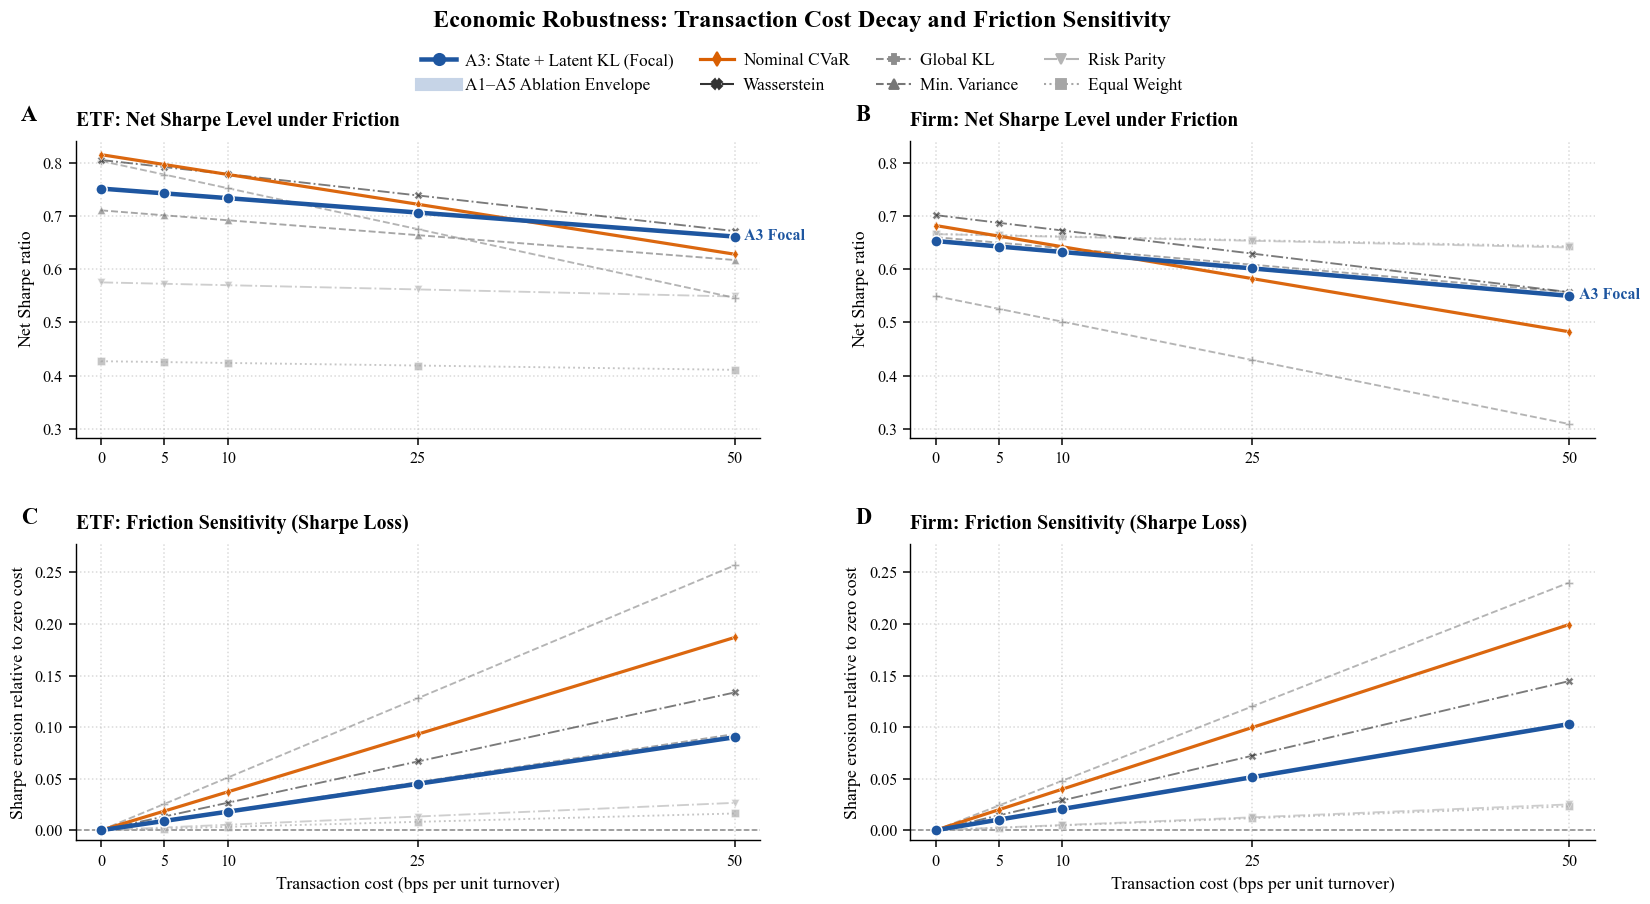

In [7]:
# -------------------------------------------------------------------------
# Figure 6
# -------------------------------------------------------------------------


file_path = (
    "C:/Users/fredy/Downloads/"
    "Section6_Q1PP_Results_V7_FIXED/csv/"
    "fig6_economic_robustness.csv"
)

df = pd.read_csv(file_path)

ablation_methods = [
    "A1_StaticLatentKL",
    "A2_StateNominal",
    "A3_StateLatentKL",
    "A4_StateQ_MeanGamma",
    "A5_StaticQ_DateGamma"
]

benchmark_methods = [
    "EqualWeight",
    "MinVariance",
    "RiskParity",
    "NominalCVaR",
    "GlobalKL",
    "Wasserstein"
]

# Calcul de SharpeLoss
df["SharpeLoss"] = np.nan
for universe in ["ETF", "Firm"]:
    for method in ablation_methods + benchmark_methods:
        mask = (df["Universe"] == universe) & (df["Method"] == method)
        g = df.loc[mask]
        sharpe_0 = float(g.loc[g["CostBps"] == 0, "Sharpe"].iloc[0])
        df.loc[mask, "SharpeLoss"] = (sharpe_0 - df.loc[mask, "Sharpe"])

# Construction de l'enveloppe A1-A5
envelope_rows = []
for universe in ["ETF", "Firm"]:
    for cost in [0, 5, 10, 25, 50]:
        g = df.loc[(df["Universe"] == universe) & (df["CostBps"] == cost) & (df["Method"].isin(ablation_methods))]
        envelope_rows.append({
            "Universe": universe,
            "CostBps": cost,
            "Sharpe_min": g["Sharpe"].min(),
            "Sharpe_max": g["Sharpe"].max(),
            "Loss_min": g["SharpeLoss"].min(),
            "Loss_max": g["SharpeLoss"].max()
        })
envelope = pd.DataFrame(envelope_rows)


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 9.5,
    "axes.labelsize": 9.5,
    "axes.titlesize": 10.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.75,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

BLUE_PRIMARY = "#1E56A0"
ORANGE = "#D95F02"

benchmark_colors = {
    "EqualWeight": "#A6A6A6",
    "MinVariance": "#777777",
    "RiskParity": "#B5B5B5",
    "NominalCVaR": ORANGE,
    "GlobalKL": "#8D8D8D",
    "Wasserstein": "#333333"
}

benchmark_styles = {
    "EqualWeight": ":",
    "MinVariance": "--",
    "RiskParity": "-.",
    "NominalCVaR": "-",
    "GlobalKL": "--",
    "Wasserstein": "-."
}

benchmark_markers = {
    "EqualWeight": "s",
    "MinVariance": "^",
    "RiskParity": "v",
    "NominalCVaR": "d",
    "GlobalKL": "P",
    "Wasserstein": "X"
}


fig, axes = plt.subplots(
    2, 2,
    figsize=(12.5, 7.),
    gridspec_kw={"width_ratios": [1.0, 1.0], "height_ratios": [1.0, 1.0]}
)

plt.subplots_adjust(
    left=0.07, right=0.97,
    bottom=0.12, top=0.86,
    wspace=0.22, hspace=0.36
)

costs = np.array([0, 5, 10, 25, 50])

level_min, level_max = df["Sharpe"].min(), df["Sharpe"].max()
level_pad = 0.05 * (level_max - level_min)
level_ylim = (level_min - level_pad, level_max + level_pad)

loss_max = df["SharpeLoss"].max()
loss_ylim = (-0.01, loss_max * 1.08)


for col_idx, universe in enumerate(["ETF", "Firm"]):

    # --- PANNEAU SUPÉRIEUR : Niveau de Sharpe Net ---
    ax_top = axes[0, col_idx]
    env = envelope[envelope["Universe"] == universe].sort_values("CostBps")

    ax_top.fill_between(
        env["CostBps"], env["Sharpe_min"], env["Sharpe_max"],
        color=BLUE_PRIMARY, alpha=0.18, zorder=1
    )

    for method in benchmark_methods:
        g = df[(df["Universe"] == universe) & (df["Method"] == method)].sort_values("CostBps")
        lw = 1.7 if method == "NominalCVaR" else 1.0
        alpha = 0.95 if method == "NominalCVaR" else 0.65
        z = 4 if method == "NominalCVaR" else 2
        ax_top.plot(
            g["CostBps"], g["Sharpe"],
            color=benchmark_colors[method], linestyle=benchmark_styles[method],
            linewidth=lw, alpha=alpha, zorder=z,
            marker=benchmark_markers[method], markersize=4.0, markeredgecolor="white", markeredgewidth=0.3
        )

    g_a3 = df[(df["Universe"] == universe) & (df["Method"] == "A3_StateLatentKL")].sort_values("CostBps")
    ax_top.plot(
        g_a3["CostBps"], g_a3["Sharpe"],
        color=BLUE_PRIMARY, linewidth=2.4, marker="o", markersize=6.0,
        markerfacecolor=BLUE_PRIMARY, markeredgecolor="white", markeredgewidth=0.8, zorder=6
    )

    # Annotation directe
    y_a3 = g_a3[g_a3["CostBps"] == 50]["Sharpe"].values[0]
    ax_top.annotate("A3 Focal", xy=(50, y_a3), xytext=(5, 0), textcoords="offset points",
                    fontsize=8.5, fontweight="bold", color=BLUE_PRIMARY, va="center")

    ax_top.set_xlim(-2, 52)
    ax_top.set_ylim(level_ylim)
    ax_top.set_xticks(costs)
    ax_top.set_ylabel("Net Sharpe ratio")
    ax_top.set_title(f"{universe}: Net Sharpe Level under Friction", fontweight="bold", pad=8, loc="left")
    ax_top.grid(True, ls=":", color="0.7", alpha=0.5)
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # --- PANNEAU INFÉRIEUR : Érosion de Sharpe ---
    ax_bot = axes[1, col_idx]

    ax_bot.fill_between(
        env["CostBps"], env["Loss_min"], env["Loss_max"],
        color=BLUE_PRIMARY, alpha=0.18, zorder=1
    )
    ax_bot.axhline(0, color="0.5", lw=0.8, ls="--", zorder=1)

    for method in benchmark_methods:
        g = df[(df["Universe"] == universe) & (df["Method"] == method)].sort_values("CostBps")
        lw = 1.7 if method == "NominalCVaR" else 1.0
        alpha = 0.95 if method == "NominalCVaR" else 0.65
        z = 4 if method == "NominalCVaR" else 2
        ax_bot.plot(
            g["CostBps"], g["SharpeLoss"],
            color=benchmark_colors[method], linestyle=benchmark_styles[method],
            linewidth=lw, alpha=alpha, zorder=z,
            marker=benchmark_markers[method], markersize=4.0, markeredgecolor="white", markeredgewidth=0.3
        )

    ax_bot.plot(
        g_a3["CostBps"], g_a3["SharpeLoss"],
        color=BLUE_PRIMARY, linewidth=2.4, marker="o", markersize=6.0,
        markerfacecolor=BLUE_PRIMARY, markeredgecolor="white", markeredgewidth=0.8, zorder=6
    )

    ax_bot.set_xlim(-2, 52)
    ax_bot.set_ylim(loss_ylim)
    ax_bot.set_xticks(costs)
    ax_bot.set_xlabel("Transaction cost (bps per unit turnover)")
    ax_bot.set_ylabel("Sharpe erosion relative to zero cost")
    ax_bot.set_title(f"{universe}: Friction Sensitivity (Sharpe Loss)", fontweight="bold", pad=8, loc="left")
    ax_bot.grid(True, ls=":", color="0.7", alpha=0.5)
    ax_bot.spines["top"].set_visible(False)
    ax_bot.spines["right"].set_visible(False)

# =========================================================================
for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):
    ax.text(-0.08, 1.05, letter, transform=ax.transAxes,
            fontsize=12, fontweight="bold", ha="left", va="bottom")

legend_handles = [
    Line2D([0], [0], color=BLUE_PRIMARY, marker="o", linewidth=2.4, markersize=6.0,
           label="A3: State + Latent KL (Focal)"),
    Line2D([0], [0], color=BLUE_PRIMARY, linewidth=7.0, alpha=0.25, label="A1–A5 Ablation Envelope"),
    Line2D([0], [0], color=ORANGE, marker="d", linewidth=1.7, markersize=5.0, label="Nominal CVaR"),
    Line2D([0], [0], color="#333333", marker="X", linestyle="-.", linewidth=1.1, markersize=5.0, label="Wasserstein"),
    Line2D([0], [0], color="#8D8D8D", marker="P", linestyle="--", linewidth=1.1, markersize=5.0, label="Global KL"),
    Line2D([0], [0], color="#777777", marker="^", linestyle="--", linewidth=1.1, markersize=5.0, label="Min. Variance"),
    Line2D([0], [0], color="#B5B5B5", marker="v", linestyle="-.", linewidth=1.1, markersize=5.0, label="Risk Parity"),
    Line2D([0], [0], color="#A6A6A6", marker="s", linestyle=":", linewidth=1.1, markersize=5.0, label="Equal Weight")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=4,
    frameon=False,
    fontsize=9.3,
    columnspacing=1.5,
    handletextpad=0.5,
    labelspacing=0.5
)

fig.suptitle(
    "Economic Robustness: Transaction Cost Decay and Friction Sensitivity",
    fontsize=13, fontweight="bold", y=0.998
)


plt.show()

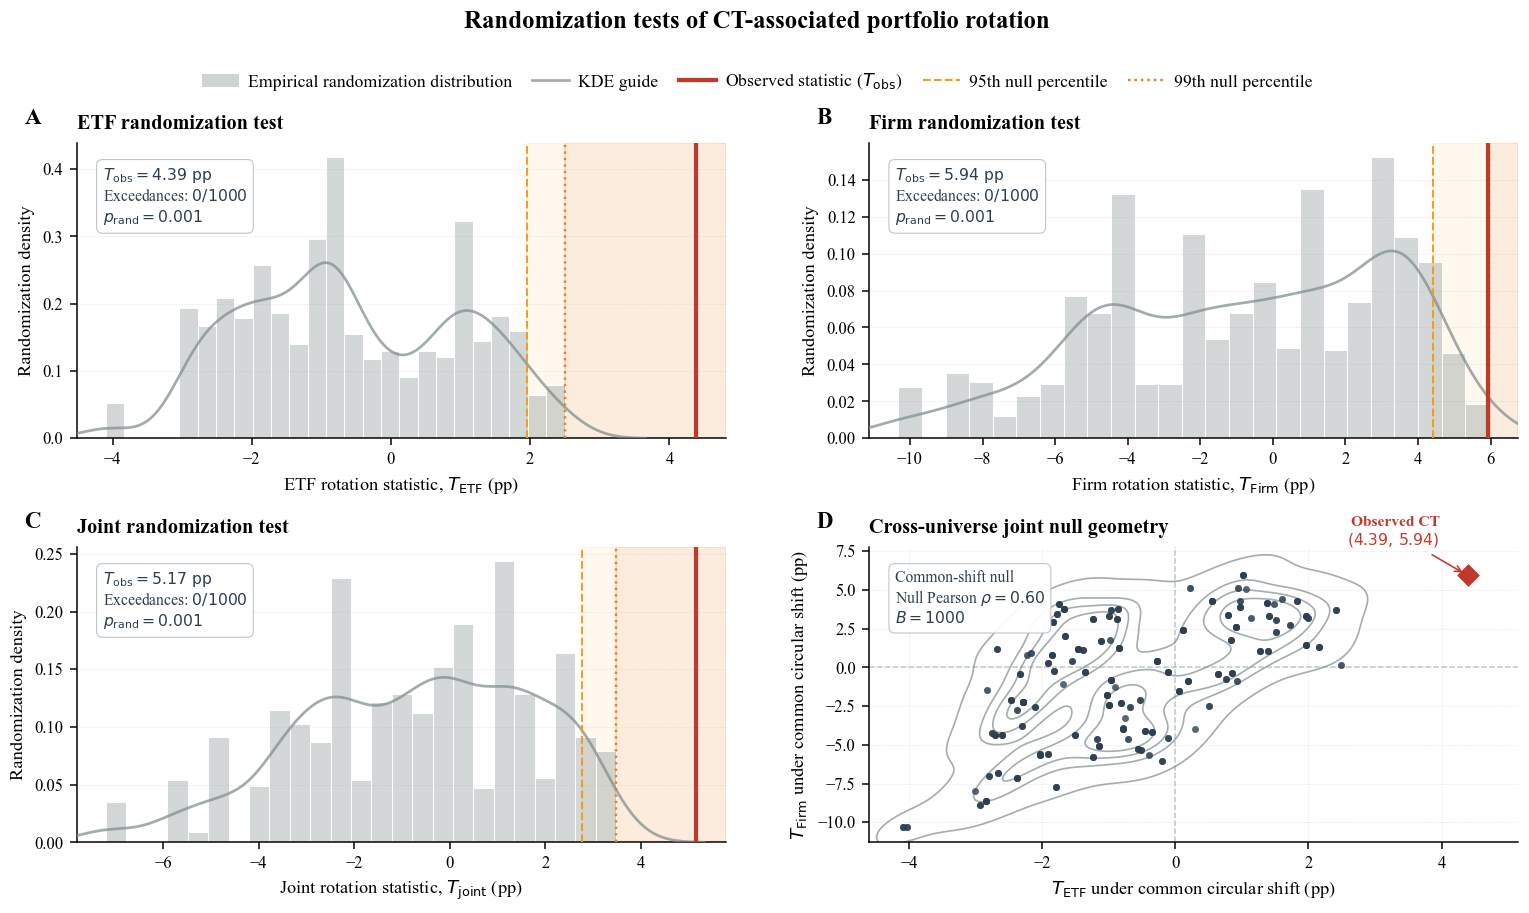

In [8]:
# -------------------------------------------------------------------------
# Figure 7
# -------------------------------------------------------------------------

file_path_A = (
    "C:/Users/fredy/Downloads/"
    "Section6_Q1PP_Results_V7_FIXED/csv/"
    "v7_ct_rotation_null_distribution.csv"
)

file_path_B = (
    "C:/Users/fredy/Downloads/"
    "Section6_Q1PP_Results_V7_FIXED/csv/"
    "v7_joint_ct_rotation_null_distribution.csv"
)

df_A = pd.read_csv(file_path_A)
df_B = pd.read_csv(file_path_B)


required_A = ["Permutation", "Shift", "T_FU", "Universe"]

required_B = ["Permutation", "Shift", "T_ETF", "T_Firm", "T_joint"]

missing_A = [col for col in required_A if col not in df_A.columns]

missing_B = [col for col in required_B if col not in df_B.columns]
null_etf_pp = (100.0 * pd.to_numeric(df_A.loc[df_A["Universe"].astype(str).str.strip().str.upper() == "ETF", "T_FU"], errors="coerce").to_numpy())

null_firm_pp = (100.0 * pd.to_numeric(df_A.loc[df_A["Universe"].astype(str).str.strip().str.upper() == "FIRM", "T_FU"], errors="coerce").to_numpy())

null_joint_pp = (100.0 * pd.to_numeric(df_B["T_joint"], errors="coerce").to_numpy())

null_etf_pp = null_etf_pp[np.isfinite(null_etf_pp)]
null_firm_pp = null_firm_pp[np.isfinite(null_firm_pp)]
null_joint_pp = null_joint_pp[np.isfinite(null_joint_pp)]


DELTA_FOSSIL_ETF = -0.0234534085672682
DELTA_UTIL_ETF   =  0.0204375505933721

DELTA_FOSSIL_FIRM = -0.310579484853215
DELTA_UTIL_FIRM   =  0.0283597768970433

T_ETF_obs = (DELTA_UTIL_ETF - DELTA_FOSSIL_ETF)

T_Firm_obs = (DELTA_UTIL_FIRM - DELTA_FOSSIL_FIRM)

T_joint_obs = (0.5 * (T_ETF_obs + T_Firm_obs))

T_ETF_obs_pp = 100.0 * T_ETF_obs
T_Firm_obs_pp = 100.0 * T_Firm_obs
T_joint_obs_pp = 100.0 * T_joint_obs


B_ETF = len(null_etf_pp)
B_Firm = len(null_firm_pp)
B_joint = len(null_joint_pp)

k_ETF = int(np.sum(null_etf_pp >= T_ETF_obs_pp))

k_Firm = int(np.sum(null_firm_pp >= T_Firm_obs_pp))

k_joint = int(np.sum(null_joint_pp >= T_joint_obs_pp))

p_ETF = ((1.0 + k_ETF) / (B_ETF + 1.0))

p_Firm = ((1.0 + k_Firm) / (B_Firm + 1.0))

p_joint = ((1.0 + k_joint) / (B_joint + 1.0))

DELTA_FOSSIL_ETF = -0.0234534085672682
DELTA_UTIL_ETF   =  0.0204375505933721

DELTA_FOSSIL_FIRM = -0.0310579484853215
DELTA_UTIL_FIRM   =  0.0283597768970433

# Universe-specific observed rotation statistics
T_ETF_obs = DELTA_UTIL_ETF - DELTA_FOSSIL_ETF
T_Firm_obs = DELTA_UTIL_FIRM - DELTA_FOSSIL_FIRM

# Cross-universe joint statistic
T_joint_obs = 0.5 * (T_ETF_obs + T_Firm_obs)

# Percentage points
T_ETF_obs_pp = 100.0 * T_ETF_obs
T_Firm_obs_pp = 100.0 * T_Firm_obs
T_joint_obs_pp = 100.0 * T_joint_obs

q95_ETF = np.quantile(null_etf_pp, 0.95)

q99_ETF = np.quantile(null_etf_pp, 0.99)

q95_Firm = np.quantile(null_firm_pp, 0.95)

q99_Firm = np.quantile(null_firm_pp, 0.99)

q95_joint = np.quantile(null_joint_pp,0.95)

q99_joint = np.quantile(null_joint_pp,0.99)

joint_x = (100.0 * pd.to_numeric(df_B["T_ETF"], errors="coerce").to_numpy())

joint_y = (100.0 * pd.to_numeric(df_B["T_Firm"], errors="coerce").to_numpy())

joint_null_from_file = (100.0 * pd.to_numeric(df_B["T_joint"], errors="coerce").to_numpy())

valid_joint = (np.isfinite(joint_x) & np.isfinite(joint_y) & np.isfinite(joint_null_from_file))

joint_x = joint_x[valid_joint]
joint_y = joint_y[valid_joint]
joint_null_from_file = joint_null_from_file[valid_joint]

rho_null = np.corrcoef(joint_x, joint_y)[0, 1]


joint_from_components_pp = (0.5 * (joint_x + joint_y))

max_joint_error = np.max(np.abs(joint_from_components_pp - joint_null_from_file))


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
        "font.size": 9.5,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10.5,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    }
)


COLOR_NULL = "#7F8C8D"

COLOR_OBS = "#C0392B"

COLOR_Q95 = "#F39C12"

COLOR_Q99 = "#E67E22"

COLOR_POINT = "#2C3E50"

COLOR_REFERENCE = "#95A5A6"


#
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.45),
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.080,
    right=0.970,
    bottom=0.155,
    top=0.850,
    wspace=0.220,
    hspace=0.370
)


# =============================================================================
# 13. PANELS A–C
# =============================================================================

panels_data = [

    (
        axes[0, 0],
        null_etf_pp,
        T_ETF_obs_pp,
        p_ETF,
        k_ETF,
        B_ETF,
        q95_ETF,
        q99_ETF,
        "ETF randomization test",
        r"ETF rotation statistic, $T_{\mathrm{ETF}}$ (pp)",
        "A"
    ),

    (
        axes[0, 1],
        null_firm_pp,
        T_Firm_obs_pp,
        p_Firm,
        k_Firm,
        B_Firm,
        q95_Firm,
        q99_Firm,
        "Firm randomization test",
        r"Firm rotation statistic, $T_{\mathrm{Firm}}$ (pp)",
        "B"
    ),

    (
        axes[1, 0],
        null_joint_pp,
        T_joint_obs_pp,
        p_joint,
        k_joint,
        B_joint,
        q95_joint,
        q99_joint,
        "Joint randomization test",
        r"Joint rotation statistic, $T_{\mathrm{joint}}$ (pp)",
        "C"
    )
]


for (ax, data, obs_val, p_val, k_val, B_val, q95, q99, title, xlabel, letter) in panels_data:

    data = np.asarray(data,dtype=float)

    data = data[np.isfinite(data)]


    # =========================================================================
    # EMPIRICAL RANDOMIZATION DISTRIBUTION
    # =========================================================================

    sns.histplot(
        data,
        bins=25,
        stat="density",
        kde=False,
        ax=ax,
        color=COLOR_NULL,
        edgecolor="white",
        alpha=0.34,
        linewidth=0.50,
        zorder=2
    )

    sns.kdeplot(
        data,
        ax=ax,
        color=COLOR_NULL,
        linewidth=1.45,
        alpha=0.72,
        fill=False,
        warn_singular=False,
        zorder=3
    )


    # =========================================================================
    # PLOTTING RANGE
    # =========================================================================

    data_min = np.nanmin(data)

    data_max = np.nanmax(data)

    full_min = min(data_min, obs_val)

    full_max = max(data_max, obs_val)

    full_range = (full_max - full_min)

    if (not np.isfinite(full_range) or full_range <= 0):
        full_range = 1.0

    x_pad = (0.050 * full_range)

    x_left = (full_min - x_pad)

    x_right = (full_max + x_pad)


    # =========================================================================
    # EMPIRICAL UPPER-TAIL REGIONS
    # =========================================================================

    ax.axvspan(
        q95,
        q99,
        color=COLOR_Q95,
        alpha=0.070,
        zorder=1
    )

    ax.axvspan(
        q99,
        x_right,
        color=COLOR_Q99,
        alpha=0.145,
        zorder=1
    )


    # =========================================================================
    # EMPIRICAL NULL PERCENTILES
    # =========================================================================

    ax.axvline(
        q95,
        color=COLOR_Q95,
        linestyle="--",
        linewidth=1.10,
        alpha=0.95,
        zorder=4
    )

    ax.axvline(
        q99,
        color=COLOR_Q99,
        linestyle=":",
        linewidth=1.30,
        alpha=0.95,
        zorder=4
    )

    # =========================================================================
    # OBSERVED STATISTIC
    # =========================================================================

    ax.axvline(
        obs_val,
        color=COLOR_OBS,
        linewidth=2.25,
        zorder=6
    )

    # =========================================================================
    # INFERENCE BOX
    # =========================================================================

    text_str = (
        rf"$T_{{\mathrm{{obs}}}}={obs_val:.2f}\ \mathrm{{pp}}$"
        "\n"
        rf"Exceedances: ${k_val}/{B_val}$"
        "\n"
        rf"$p_{{\mathrm{{rand}}}}={p_val:.3f}$"
    )

    ax.text(
        0.040,
        0.925,
        text_str,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.35,
        linespacing=1.25,
        color="#2C3E50",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor="white",
            edgecolor="#BDC3C7",
            alpha=0.94,
            linewidth=0.60
        ),
        zorder=10
    )

    # =========================================================================
    # AXES
    # =========================================================================

    ax.set_xlim(x_left, x_right)

    ax.set_xlabel(xlabel, fontsize=9.8)

    ax.set_ylabel("Randomization density", fontsize=9.8)

    ax.set_title(
        title,
        fontsize=10.8,
        fontweight="semibold",
        pad=8,
        loc="left"
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.55,
        alpha=0.28,
        color="0.65"
    )

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.80)

    ax.spines["bottom"].set_linewidth(0.80)

    ax.tick_params(axis="both", labelsize=8.8)


    # =========================================================================
    # PANEL LETTER
    # =========================================================================

    ax.text(
        -0.080,
        1.050,
        letter,
        transform=ax.transAxes,
        fontsize=12.2,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False
    )

ax = axes[1, 1]

# =============================================================================
# EMPIRICAL 2D NULL GEOMETRY
# =============================================================================

sns.kdeplot(
    x=joint_x,
    y=joint_y,
    ax=ax,
    levels=5,
    thresh=0.05,
    color=COLOR_NULL,
    linewidths=0.90,
    alpha=0.70,
    zorder=2
)

ax.scatter(
    joint_x,
    joint_y,
    s=13,
    color=COLOR_POINT,
    alpha=0.32,
    linewidth=0,
    rasterized=True,
    zorder=3
)


# =============================================================================
# ZERO-ROTATION REFERENCE AXES
# =============================================================================

ax.axvline(
    0,
    color=COLOR_REFERENCE,
    linewidth=0.80,
    linestyle="--",
    alpha=0.60,
    zorder=1
)

ax.axhline(
    0,
    color=COLOR_REFERENCE,
    linewidth=0.80,
    linestyle="--",
    alpha=0.60,
    zorder=1
)


# =============================================================================
# OBSERVED CT CONFIGURATION
# =============================================================================

ax.scatter(
    T_ETF_obs_pp,
    T_Firm_obs_pp,
    s=92,
    marker="D",
    color=COLOR_OBS,
    edgecolor="white",
    linewidth=1.0,
    zorder=7
)

ax.annotate(
    "Observed CT\n"
    + rf"$({T_ETF_obs_pp:.2f},\,{T_Firm_obs_pp:.2f})$",
    xy=(
        T_ETF_obs_pp,
        T_Firm_obs_pp
    ),
    xytext=(-15, 14),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=8.25,
    fontweight="semibold",
    color=COLOR_OBS,
    arrowprops=dict(
        arrowstyle="->",
        color=COLOR_OBS,
        lw=0.85,
        shrinkA=2,
        shrinkB=3
    ),
    zorder=8
)


# =============================================================================
# NULL-DEPENDENCE INFORMATION
# =============================================================================

null_text = (
    "Common-shift null"
    "\n"
    + rf"Null Pearson $\rho={rho_null:.2f}$"
    "\n"
    + rf"$B={len(joint_x)}$"
)

ax.text(
    0.040,
    0.925,
    null_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.35,
    linespacing=1.25,
    color="#2C3E50",
    bbox=dict(
        boxstyle="round,pad=0.38",
        facecolor="white",
        edgecolor="#BDC3C7",
        alpha=0.94,
        linewidth=0.60
    ),
    zorder=10
)

x_min = min(np.min(joint_x), T_ETF_obs_pp)

x_max = max(np.max(joint_x), T_ETF_obs_pp)

y_min = min(np.min(joint_y), T_Firm_obs_pp)

y_max = max(np.max(joint_y), T_Firm_obs_pp)

x_range = (x_max - x_min)

y_range = (y_max - y_min)

if x_range <= 0:
    x_range = 1.0

if y_range <= 0:
    y_range = 1.0

ax.set_xlim(
    x_min - 0.06 * x_range,
    x_max + 0.09 * x_range
)

ax.set_ylim(
    y_min - 0.06 * y_range,
    y_max + 0.11 * y_range
)


# =============================================================================
# PANEL D AXES
# =============================================================================

ax.set_xlabel(r"$T_{\mathrm{ETF}}$ under common circular shift (pp)", fontsize=9.8)

ax.set_ylabel(r"$T_{\mathrm{Firm}}$ under common circular shift (pp)", fontsize=9.8)

ax.set_title(
    "Cross-universe joint null geometry",
    fontsize=10.8,
    fontweight="semibold",
    pad=8,
    loc="left"
)

ax.grid(
    linestyle=":",
    linewidth=0.55,
    alpha=0.25,
    color="0.65"
)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.80)

ax.spines["bottom"].set_linewidth(0.80)

ax.tick_params(axis="both", labelsize=8.8)


# =============================================================================
# PANEL D LETTER
# =============================================================================

ax.text(
    -0.080,
    1.050,
    "D",
    transform=ax.transAxes,
    fontsize=12.2,
    fontweight="bold",
    ha="left",
    va="bottom",
    clip_on=False
)


# =============================================================================
# 15. GLOBAL TITLE
# =============================================================================

fig.suptitle(
    "Randomization tests of CT-associated portfolio rotation",
    fontsize=13.2,
    fontweight="semibold",
    y=0.982
)



legend_handles = [

    Patch(
        facecolor=COLOR_NULL,
        edgecolor="none",
        alpha=0.38,
        label="Empirical randomization distribution"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NULL,
        linewidth=1.45,
        alpha=0.72,
        label="KDE guide"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_OBS,
        linewidth=2.25,
        label=r"Observed statistic ($T_{\mathrm{obs}}$)"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_Q95,
        linestyle="--",
        linewidth=1.10,
        label="95th null percentile"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_Q99,
        linestyle=":",
        linewidth=1.30,
        label="99th null percentile"
    )
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.937),
    ncol=5,
    frameon=False,
    fontsize=9.45,
    columnspacing=1.15,
    handlelength=2.10,
    handletextpad=0.50
)


plt.show()